![display relevant image here](path/url/to/image)
- Banner/header image

# Financial Risk Modeling for Loan Approval
**Objective**
Building a reliable credit decision support model to predict whether a loan application should be approved.

## Overview
- BLUF (Bottom Line Up Front)
- One paragraph summary of final model performance and business implications
- Frame your 'story'

# Financial Risk Modelling for Loan Approval

## Project objective
This notebook develops and evaluates a credit decision-support model to estimate the probability that a loan application will be approved. It uses a synthetic financial-loan dataset and demonstrates a complete, reproducible workflow: business and data understanding, data-quality assessment, preprocessing, model development, tuning, evaluation, feature interpretation, and implementation recommendations.

> **Important use note:** The model is a decision-support tool. It should not replace credit policy, affordability assessment, human review, customer-consent requirements, or fairness and compliance controls.

## 1. Business Understanding

FinTech Innovations currently relies heavily on manual review of loan applications. This can create slow turnaround times, inconsistent application of lending criteria, limited capacity to analyse many applications at once, and difficulty explaining portfolio-level approval patterns.

The business objective is to develop a reliable **binary classification** model that estimates the likelihood of `LoanApproved` (1 = approved; 0 = not approved) from applicant, loan, credit, affordability and financial-position information. The model should support—not automate without oversight—faster, more consistent and evidence-based credit decisions.

### Success criteria
- **Primary metric:** ROC–AUC, because the approval class is a minority class and the lender needs a model that ranks applications effectively across possible decision thresholds.
- **Supporting metrics:** precision, recall, F1-score, confusion matrix and segment-level performance checks.
- **Operational objective:** reduce manual screening effort while preserving prudent credit decisions, explainability and fair-treatment safeguards.

### Stakeholders and use case
The intended users are credit officers, risk managers and portfolio-management teams. They can use predicted probabilities to prioritise review, identify applications requiring additional evidence and monitor approval drivers. Final lending decisions remain subject to policy rules, affordability analysis and appropriate human approval.

## 2. Data Understanding

The dataset contains **20,000 loan applications** and **35 columns**. It combines applicant demographics, employment, education, credit behaviour, loan terms, income, assets, liabilities and the target variable, `LoanApproved`.

Initial inspection shows that `AnnualIncome` is stored as a currency-formatted string and must be converted to numeric form before analysis. The target is imbalanced: approximately **23.9%** of applications are approved and **76.1%** are not approved. This makes ROC–AUC, precision, recall and F1-score more informative than accuracy alone.

Three fields contain missing values: `MaritalStatus` (about **6.66%**), `EducationLevel` (about **4.51%**) and `SavingsAccountBalance` (about **2.86%**). No exact duplicate records were identified. The field `RiskScore` is excluded from predictive modelling because it may be created from information closely related to the approval decision and could therefore introduce target leakage.

In [1]:
# Import the necessary libraries
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import randint
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score, roc_curve
)
from sklearn.model_selection import (
    GridSearchCV, RandomizedSearchCV, StratifiedKFold, train_test_split
)
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)


In [2]:
# Load dataset
# The CSV file should be kept in the same folder as this notebook.
data_path = Path('financial_loan_data.csv')
df = pd.read_csv(data_path)
df.head()


,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,Own,183,0.354418,1,2,0.358336,No,Home,0,29,9,7632.0,1202,146111,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.087827,5,3,0.330274,No,Debt Consolidation,0,21,9,4627.0,3460,53204,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,Rent,902,0.137414,2,0,0.244729,No,Education,0,20,22,886.0,895,25176,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.267587,2,1,0.436244,No,Home,0,27,10,1675.0,1217,104822,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.320535,0,0,0.078884,No,Debt Consolidation,0,26,27,1555.0,4981,244305,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [3]:
df.tail()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
19995,44,"$30,180.00",587,Employed,High School,19,24521,36,Married,3,Rent,673,0.101288,5,1,0.468077,No,Auto,0,21,7,235.0,3429,80969,25642,2515.000000,0.826217,1,55327,0.216021,0.195574,905.767712,0.627741,0,55.0
19996,56,"$49,246.00",567,Employed,Associate,33,25818,36,Married,5,Rent,414,0.471818,2,0,0.317372,No,Debt Consolidation,0,30,28,6910.0,183,69571,5569,4103.833333,0.816618,3,64002,0.227318,0.199168,958.395633,0.334418,0,54.0
19997,44,"$48,958.00",645,Employed,Bachelor,20,37033,72,Married,3,Mortgage,512,0.216596,3,1,0.023014,No,Home,0,28,8,2175.0,746,108316,4653,4079.833333,0.887216,3,103663,0.229533,0.226766,945.427454,0.357227,0,45.0
19998,60,"$41,025.00",560,Employed,NaN,36,14760,72,NaN,3,Own,986,0.364758,4,1,0.534517,No,Debt Consolidation,0,17,13,3037.0,260,22085,11485,3418.750000,0.843787,5,10600,0.249760,0.264873,411.168284,0.408678,0,59.0
19999,20,"$53,227.00",574,Employed,Associate,0,32055,48,Married,0,Own,272,0.536411,3,1,0.553434,No,Other,0,36,14,2682.0,1766,83008,41636,4435.583333,0.853801,5,41372,0.240055,0.242693,1049.830407,0.298006,0,59.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

In [5]:
# Statistical summary
df.describe()

,Age,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,19428.000000,20000.000000,2.000000e+04,2.000000e+04,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,39.752600,571.612400,17.522750,24882.867800,54.057000,1.517300,454.292700,0.286381,3.023350,0.993000,0.285735,0.100050,23.993650,14.957300,4949.148446,1782.555100,9.696440e+04,3.625241e+04,4891.715521,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000,50.766780
std,11.622713,50.997358,11.316836,13427.421217,24.664857,1.386325,240.507609,0.159793,1.736161,0.986965,0.160211,0.300074,4.945436,8.371552,6628.404969,2245.378812,1.207999e+05,4.725151e+04,3296.771598,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483,7.778262
min,18.000000,343.000000,0.000000,3674.000000,12.000000,0.000000,50.000000,0.000974,0.000000,0.000000,0.001720,0.000000,8.000000,1.000000,73.000000,24.000000,2.098000e+03,3.720000e+02,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,28.800000
25%,32.000000,540.000000,9.000000,15575.000000,36.000000,0.000000,286.000000,0.160794,2.000000,0.000000,0.161035,0.000000,21.000000,8.000000,1542.000000,551.000000,3.118025e+04,1.119675e+04,2629.583333,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000,46.000000
50%,40.000000,578.000000,17.000000,21914.500000,48.000000,1.000000,402.000000,0.266673,3.000000,1.000000,0.264454,0.000000,24.000000,15.000000,2988.500000,1116.000000,6.069900e+04,2.220300e+04,4034.750000,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000,52.000000
75%,48.000000,609.000000,25.000000,30835.000000,72.000000,2.000000,564.000000,0.390634,4.000000,2.000000,0.390327,0.000000,27.000000,22.000000,5869.250000,2126.000000,1.174052e+05,4.314650e+04,6163.000000,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770759,0.509214,0.000000,56.000000
max,80.000000,712.000000,61.000000,184732.000000,120.000000,5.000000,2919.000000,0.917380,13.000000,7.000000,0.902253,1.000000,45.000000,29.000000,200089.000000,52572.000000,2.619627e+06,1.417302e+06,25000.000000,0.999433,16.000000,2.603208e+06,0.405029,0.446787,10892.629520,4.647657,1.000000,84.000000


In [6]:
# Check column names
print(df.columns)

Index(['Age', 'AnnualIncome', 'CreditScore', 'EmploymentStatus',
       'EducationLevel', 'Experience', 'LoanAmount', 'LoanDuration',
       'MaritalStatus', 'NumberOfDependents', 'HomeOwnershipStatus',
       'MonthlyDebtPayments', 'CreditCardUtilizationRate',
       'NumberOfOpenCreditLines', 'NumberOfCreditInquiries',
       'DebtToIncomeRatio', 'BankruptcyHistory', 'LoanPurpose',
       'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory',
       'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets',
       'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory',
       'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate',
       'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved',
       'RiskScore'],
      dtype='object')


In [7]:
df.dtypes

Age                             int64
AnnualIncome                   object
CreditScore                     int64
EmploymentStatus               object
EducationLevel                 object
Experience                      int64
LoanAmount                      int64
LoanDuration                    int64
MaritalStatus                  object
NumberOfDependents              int64
HomeOwnershipStatus            object
MonthlyDebtPayments             int64
CreditCardUtilizationRate     float64
NumberOfOpenCreditLines         int64
NumberOfCreditInquiries         int64
DebtToIncomeRatio             float64
BankruptcyHistory              object
LoanPurpose                    object
PreviousLoanDefaults            int64
PaymentHistory                  int64
LengthOfCreditHistory           int64
SavingsAccountBalance         float64
CheckingAccountBalance          int64
TotalAssets                     int64
TotalLiabilities                int64
MonthlyIncome                 float64
UtilityBills

In [8]:
# Check dataset size
print(df.shape)

(20000, 35)


This dataset has 20000 rows and 35 columns

## Data cleaning

In [9]:
# Checking for missing values
df.isnull().sum()

Age                              0
AnnualIncome                     0
CreditScore                      0
EmploymentStatus                 0
EducationLevel                 901
Experience                       0
LoanAmount                       0
LoanDuration                     0
MaritalStatus                 1331
NumberOfDependents               0
HomeOwnershipStatus              0
MonthlyDebtPayments              0
CreditCardUtilizationRate        0
NumberOfOpenCreditLines          0
NumberOfCreditInquiries          0
DebtToIncomeRatio                0
BankruptcyHistory                0
LoanPurpose                      0
PreviousLoanDefaults             0
PaymentHistory                   0
LengthOfCreditHistory            0
SavingsAccountBalance          572
CheckingAccountBalance           0
TotalAssets                      0
TotalLiabilities                 0
MonthlyIncome                    0
UtilityBillsPaymentHistory       0
JobTenure                        0
NetWorth            

In [10]:
# Checking for duplicates
df.duplicated().sum()

0

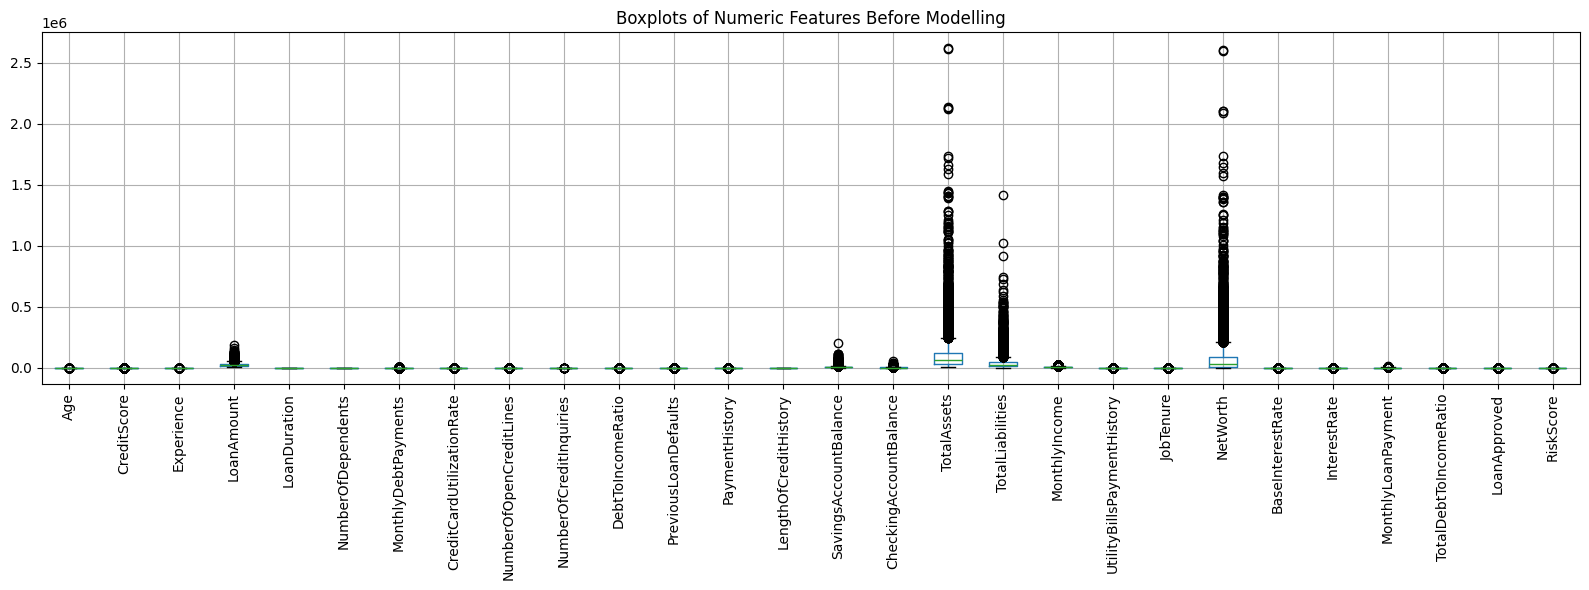

In [11]:
# Check potential outliers in numeric variables only
# AnnualIncome is converted to numeric in the next data-cleaning step.
plot_columns = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(16, 6))
df[plot_columns].boxplot(rot=90)
plt.title('Boxplots of Numeric Features Before Modelling')
plt.tight_layout()
plt.show()


## Examine distributions of all features and target variables

In [12]:
# Clean 'AnnualIncome' column
df['AnnualIncome'] = df['AnnualIncome'].replace('[$,]', '', regex=True).astype(float)
print("Cleaned 'AnnualIncome' column to numeric type.")

Cleaned 'AnnualIncome' column to numeric type.


In [13]:
# Separate features by type for targeted plotting
numeric_features = df.select_dtypes(include=['float64', 'int64']).columns
categorical_features = df.select_dtypes(include=['object']).columns


## 7. Model Optimisation — Setup

This cell records the optimisation approach used later in the notebook. The actual hyperparameter searches are intentionally executed after the preprocessing and baseline-model sections so that all transformations are fitted only on the training data.

In [14]:
# Model-optimisation setup (the searches are executed later in Section 7)
# RiskScore is deliberately excluded to avoid potential target leakage.
# Keeping this setup here preserves the original notebook sequence while
# allowing the later modelling and tuning cells to reuse the same conventions.
drop_cols = ['LoanApproved', 'RiskScore']
model_target = 'LoanApproved'

print('Optimisation setup complete.')
print('Target:', model_target)
print('Excluded from modelling:', 'RiskScore (potential leakage)')


Optimisation setup complete.
Target: LoanApproved
Excluded from modelling: RiskScore (potential leakage)


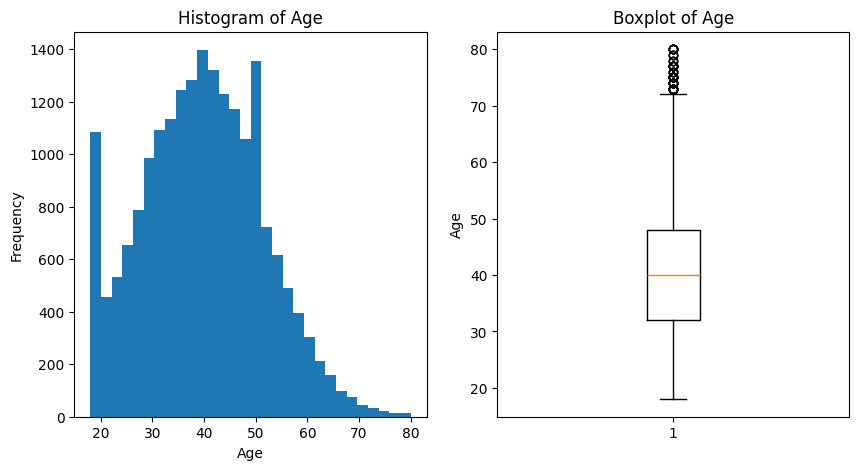

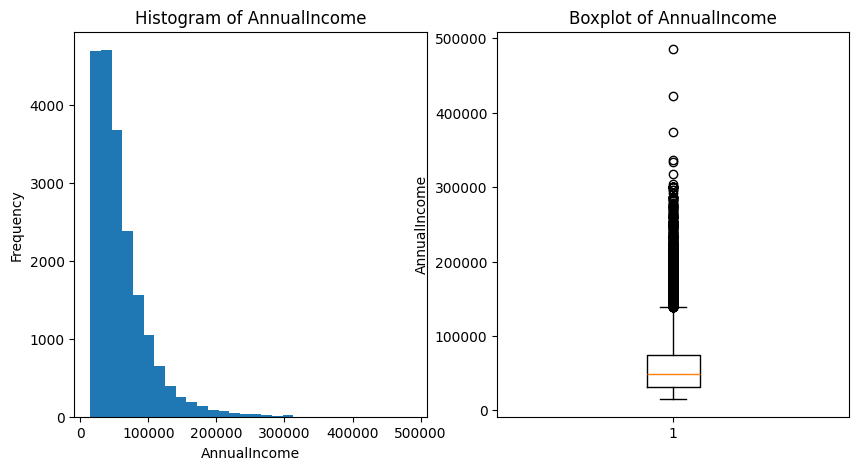

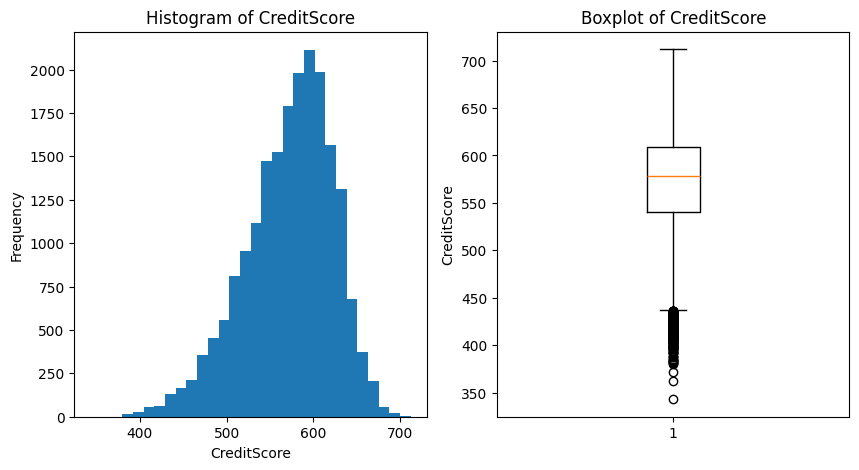

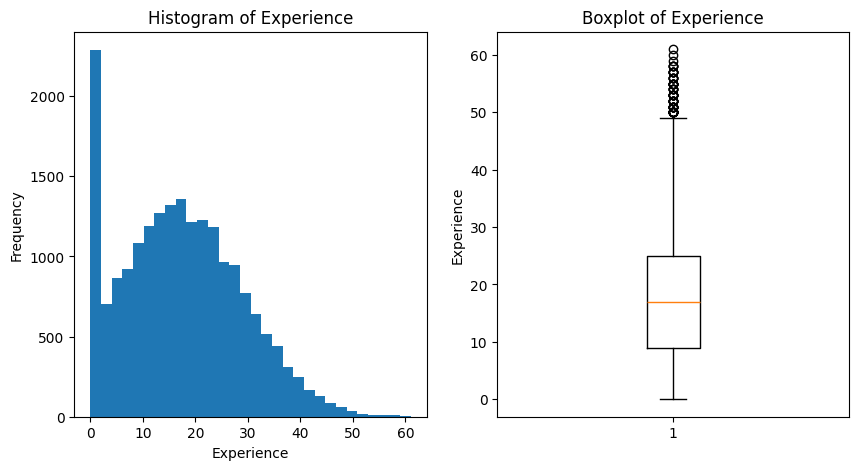

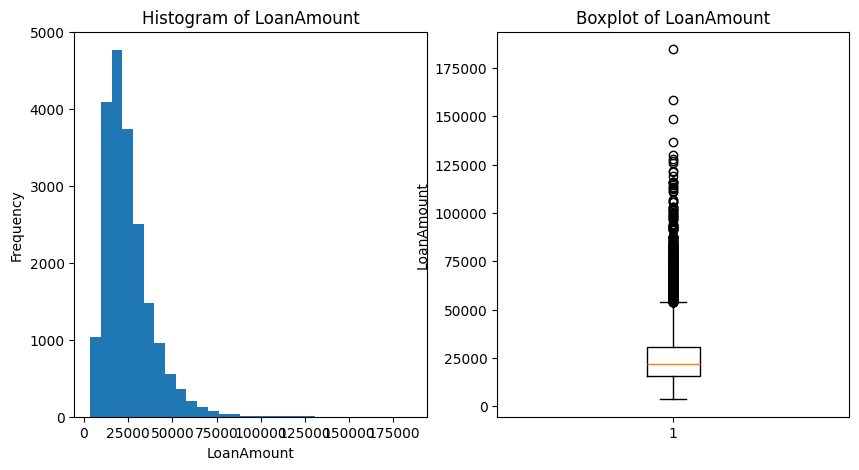

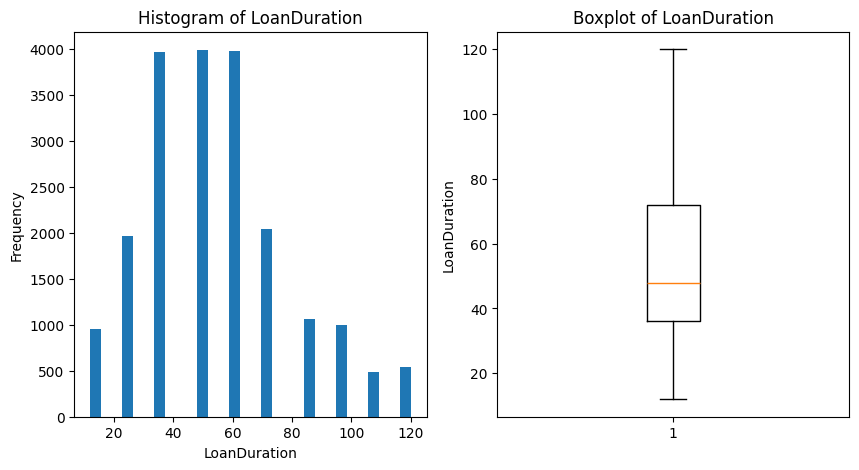

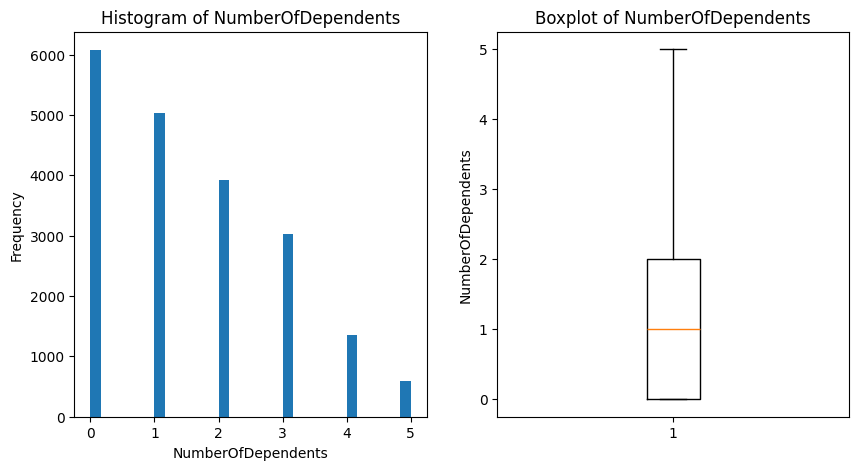

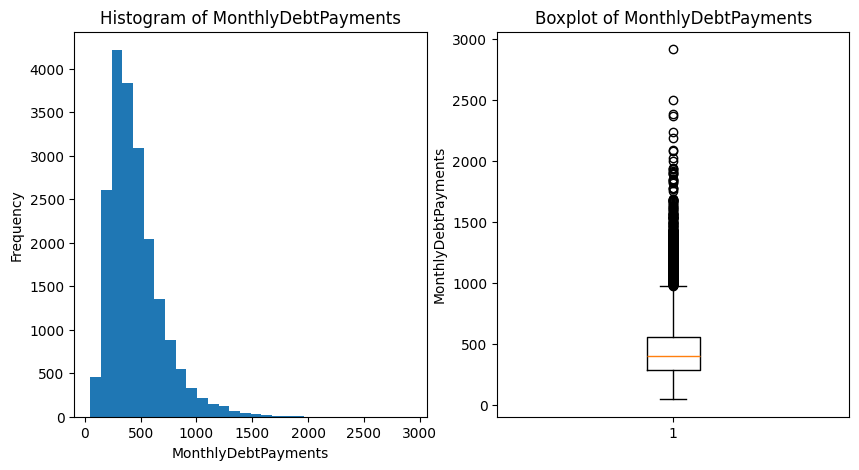

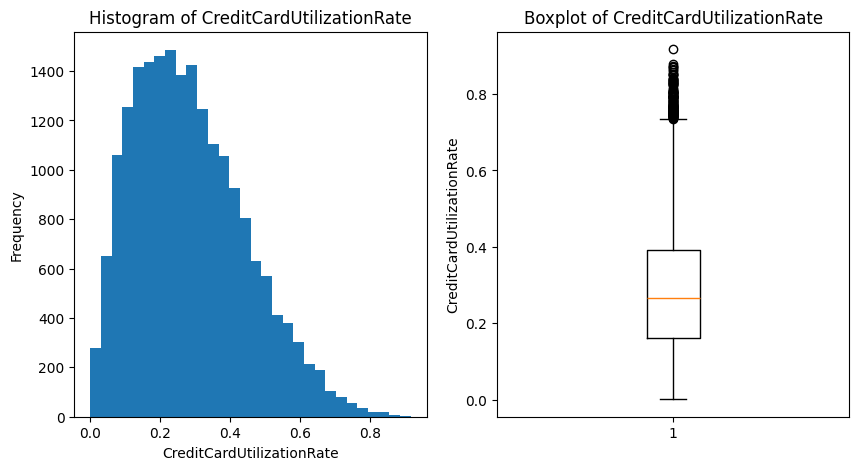

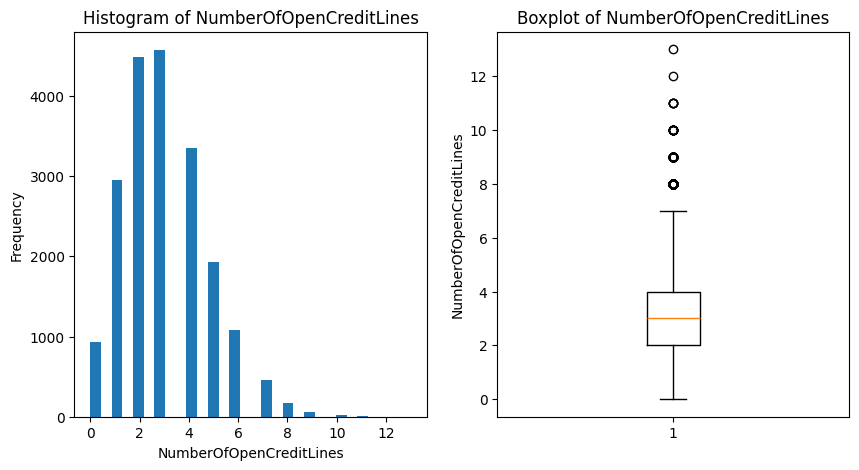

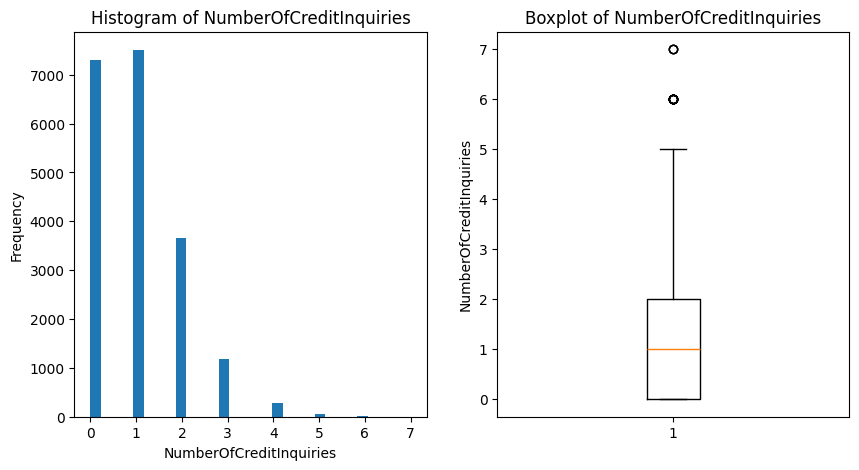

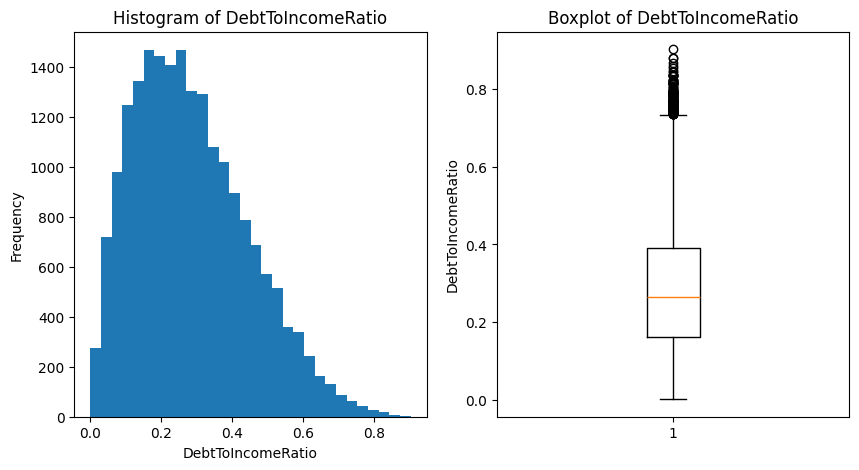

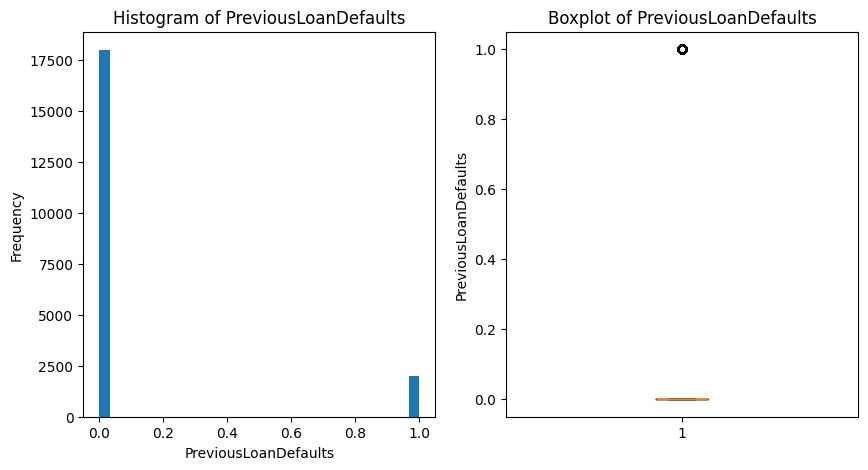

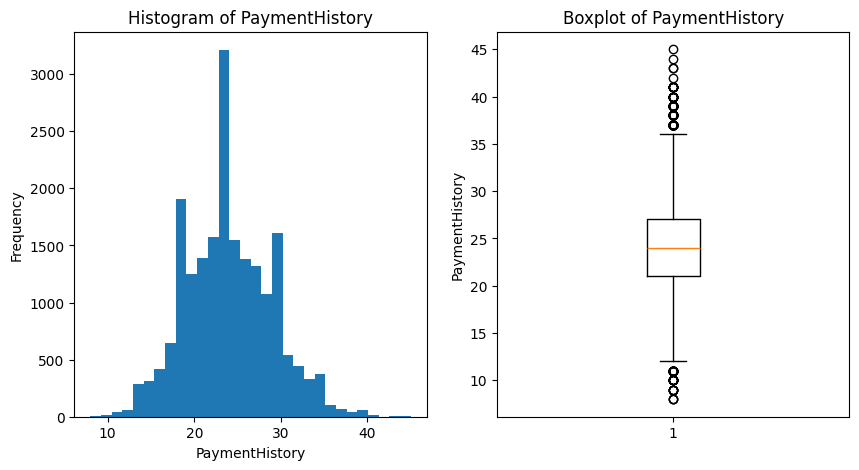

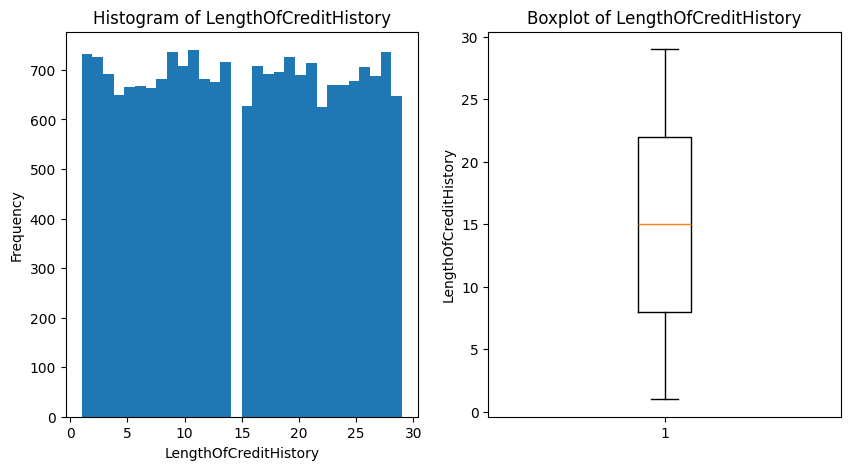

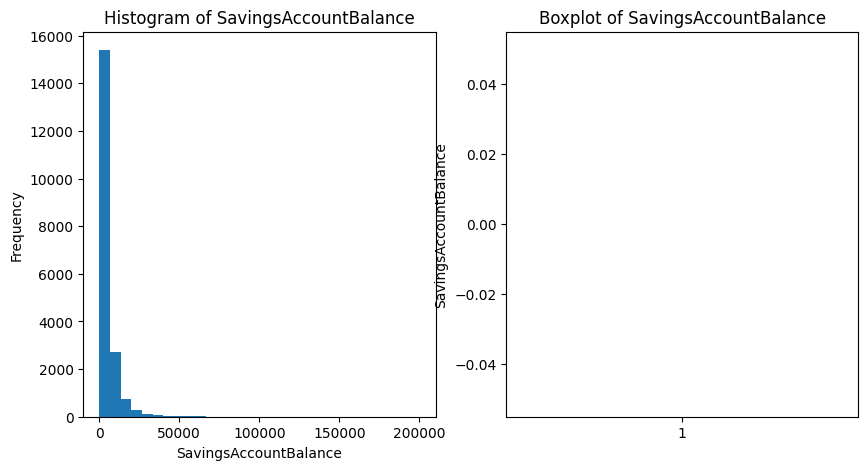

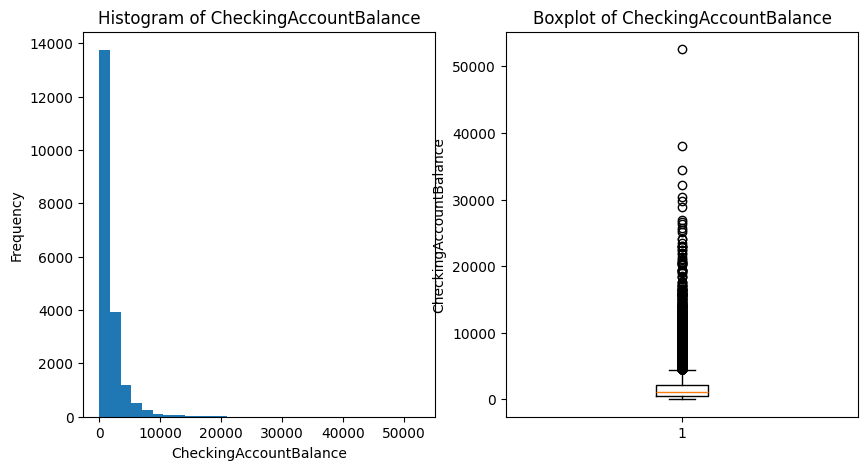

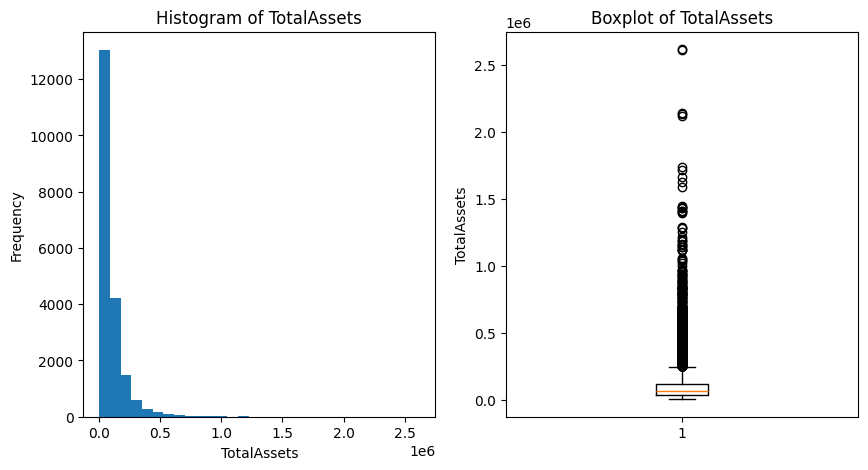

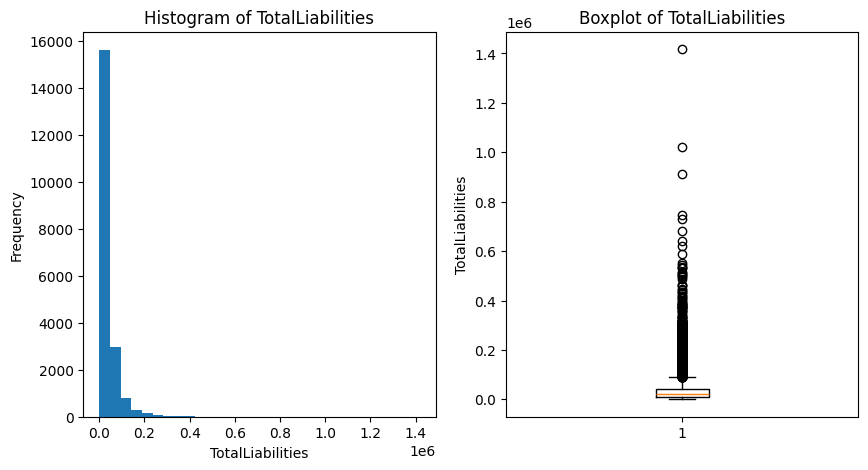

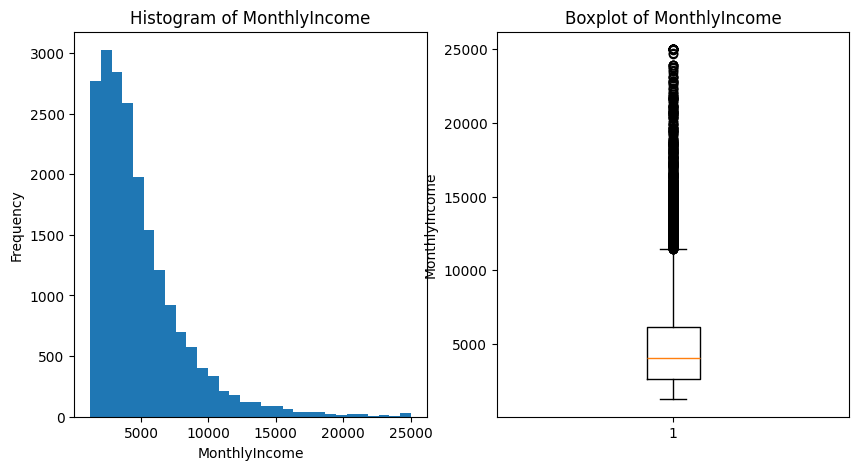

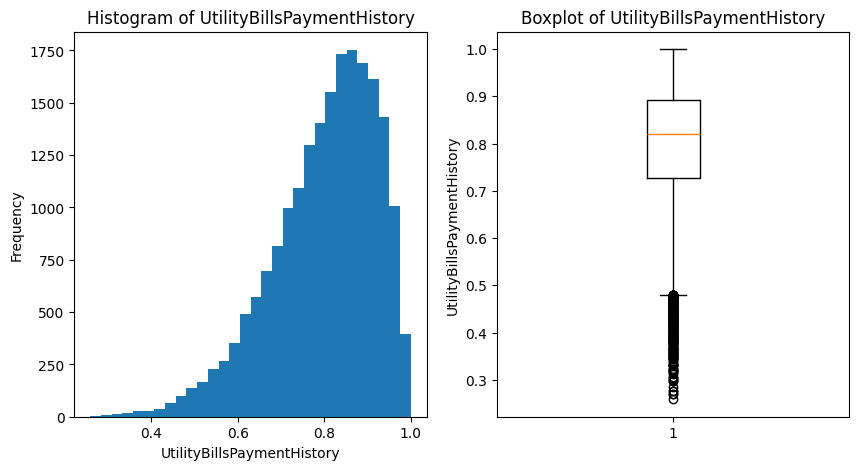

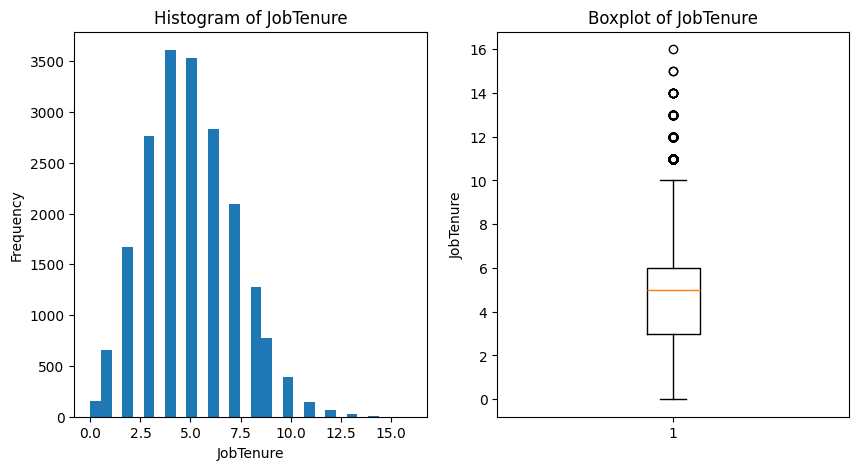

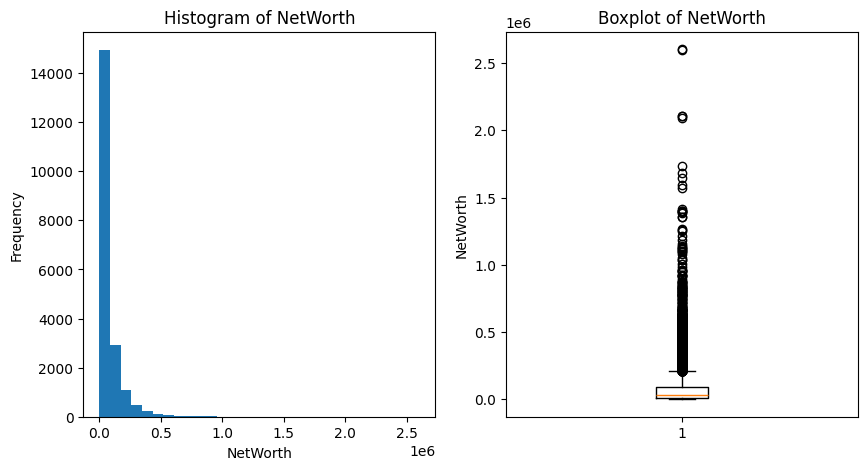

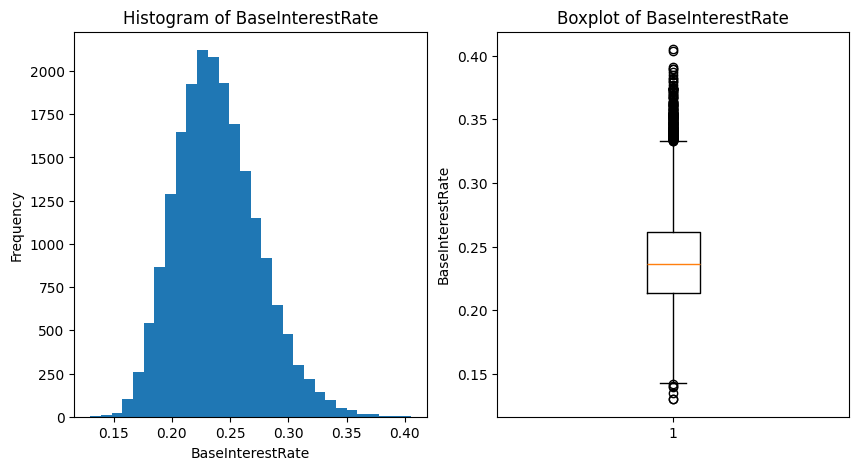

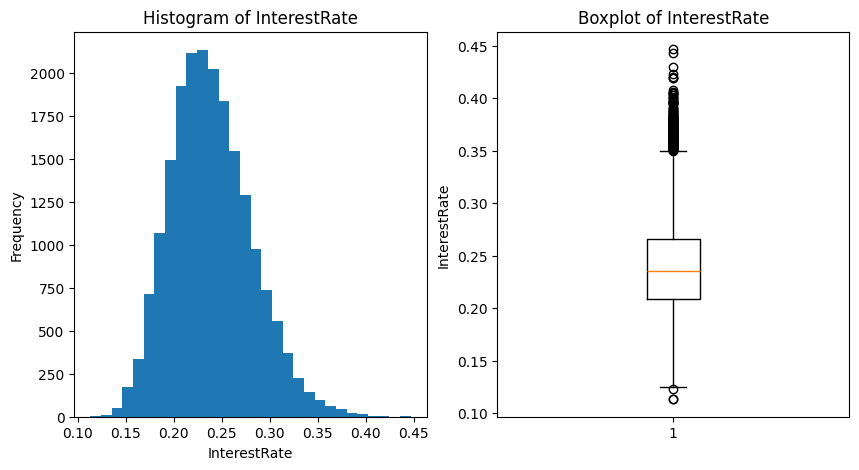

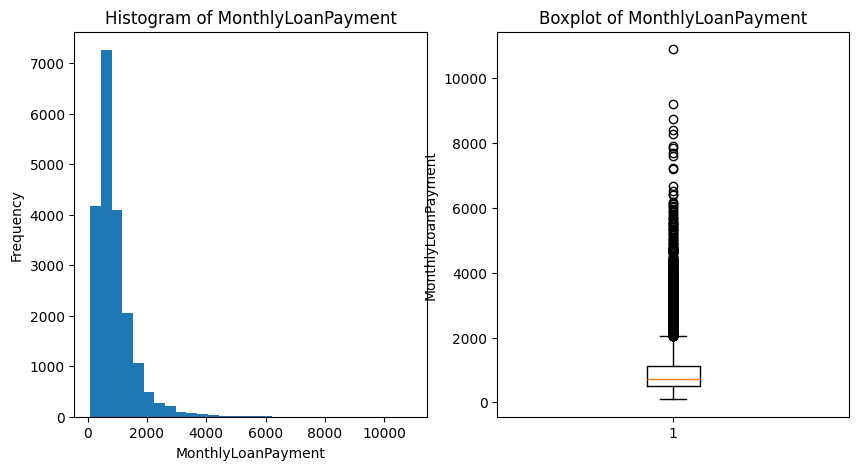

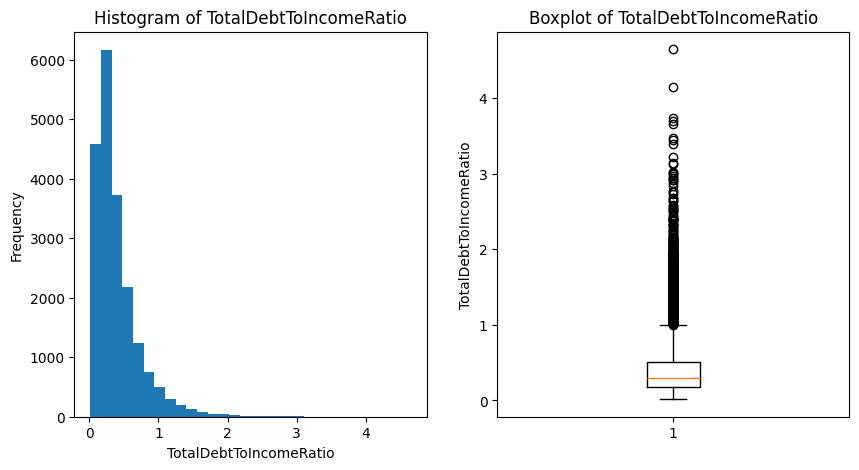

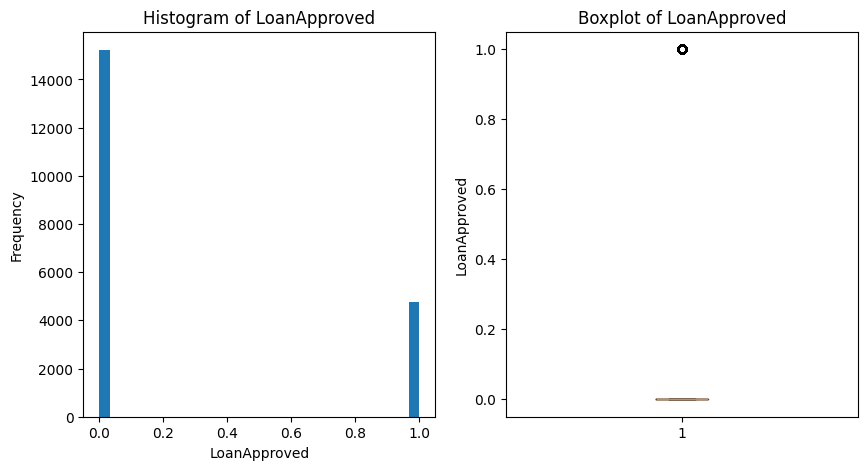

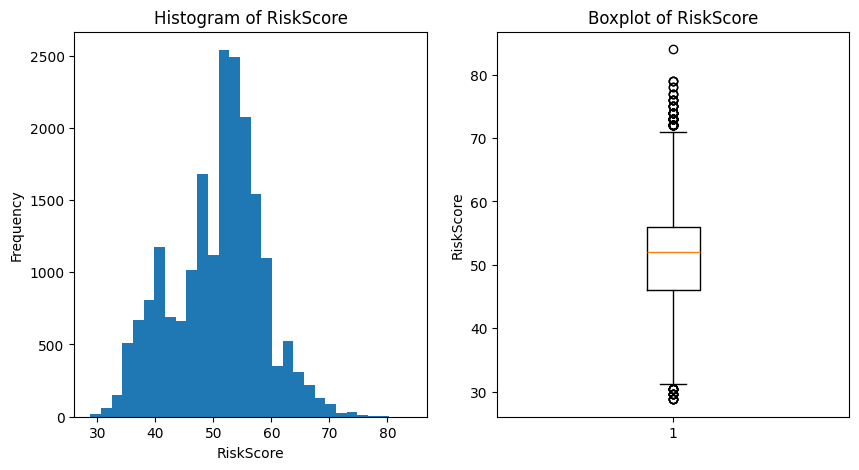

In [15]:
# Plot numerical distributions using histograms and boxplots
for feature in numeric_features:
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.hist(df[feature], bins=30)
    plt.title(f'Histogram of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    
    plt.subplot(1,2,2)
    plt.boxplot(df[feature])
    plt.title(f'Boxplot of {feature}')
    plt.ylabel(feature)
    plt.show()

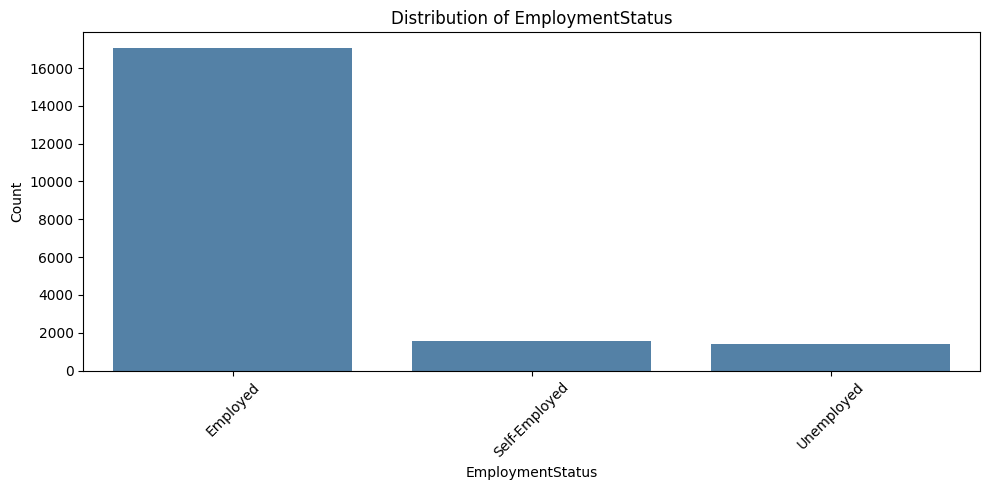

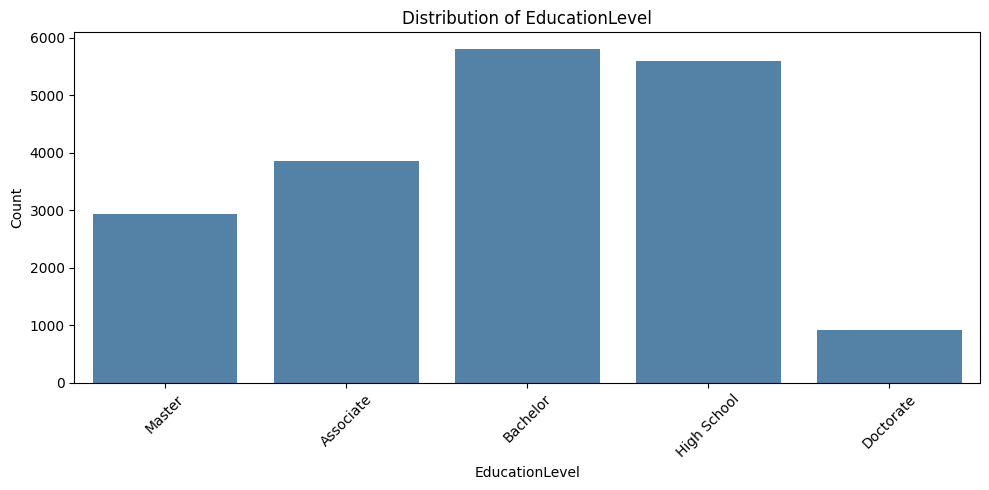

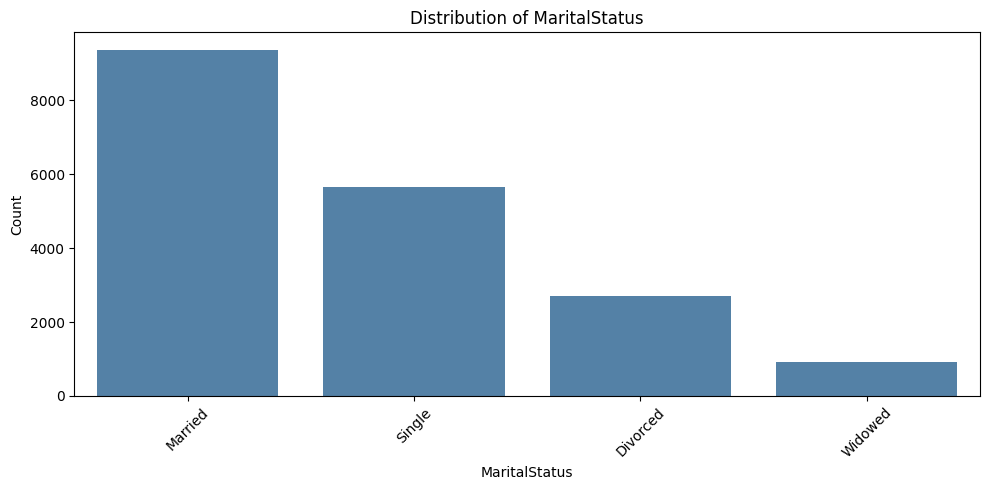

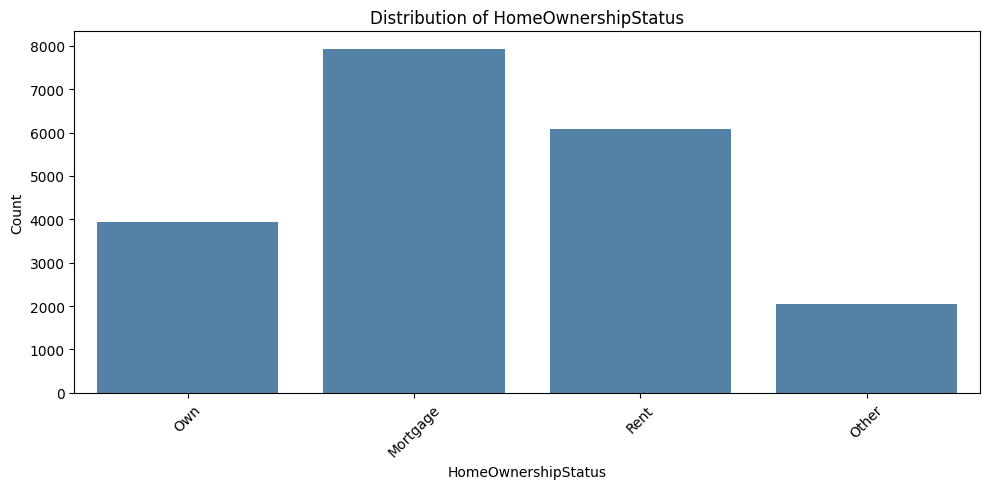

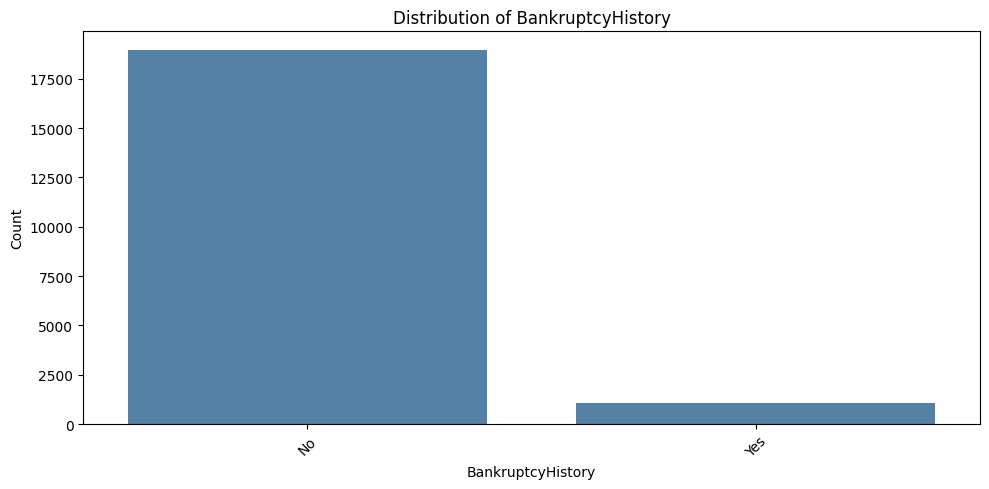

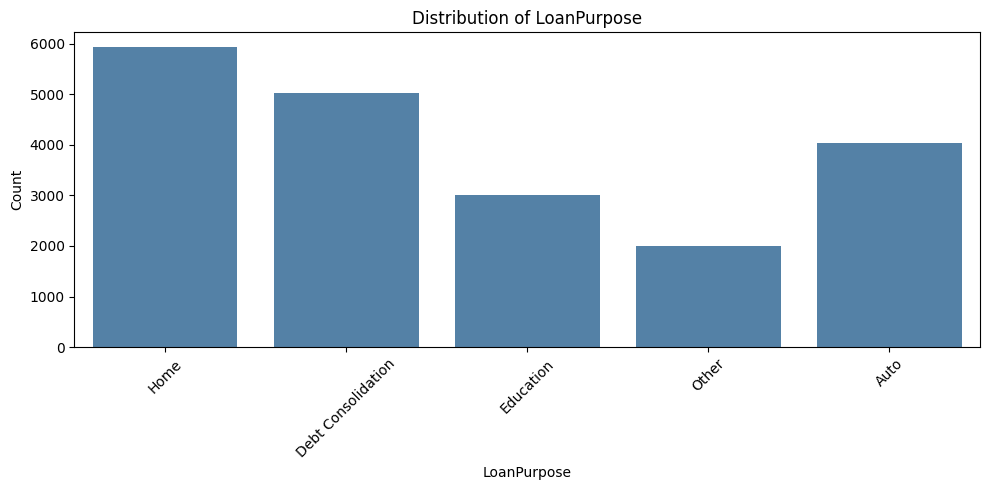

In [16]:
# Plot categorical distributions using count plots
for feature in categorical_features:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=feature, color='steelblue')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Investigate relationships between features

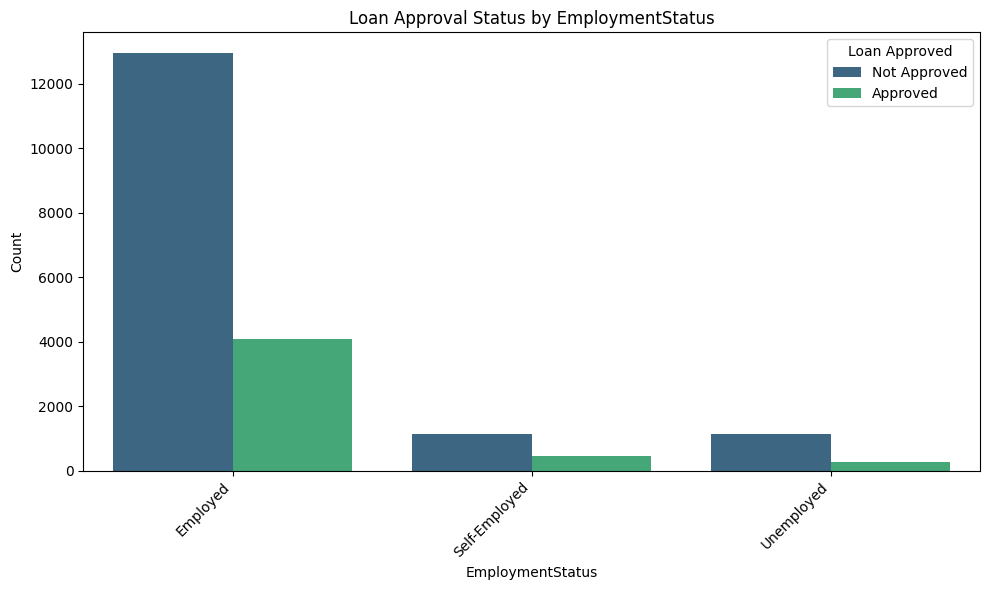

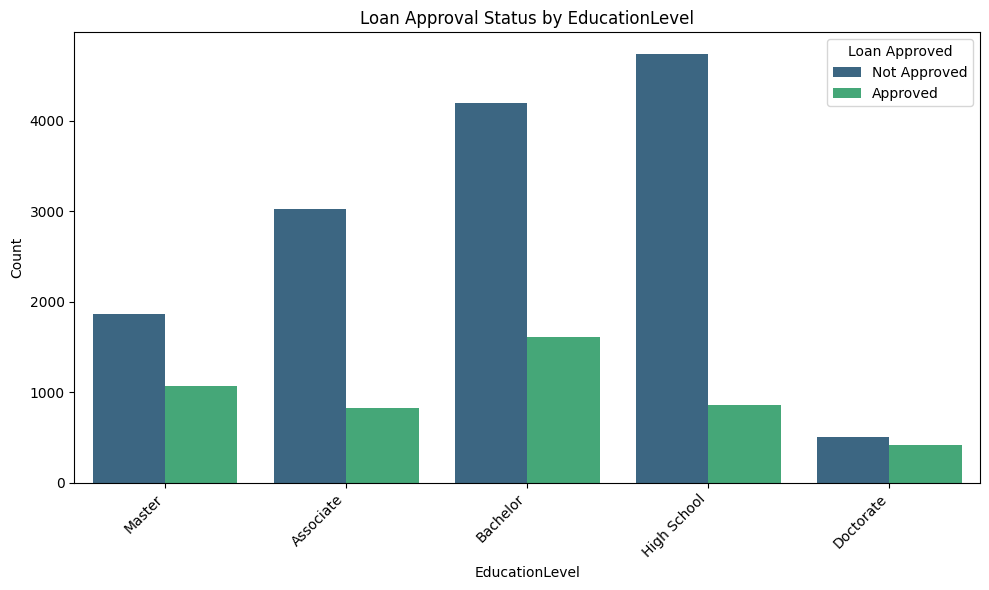

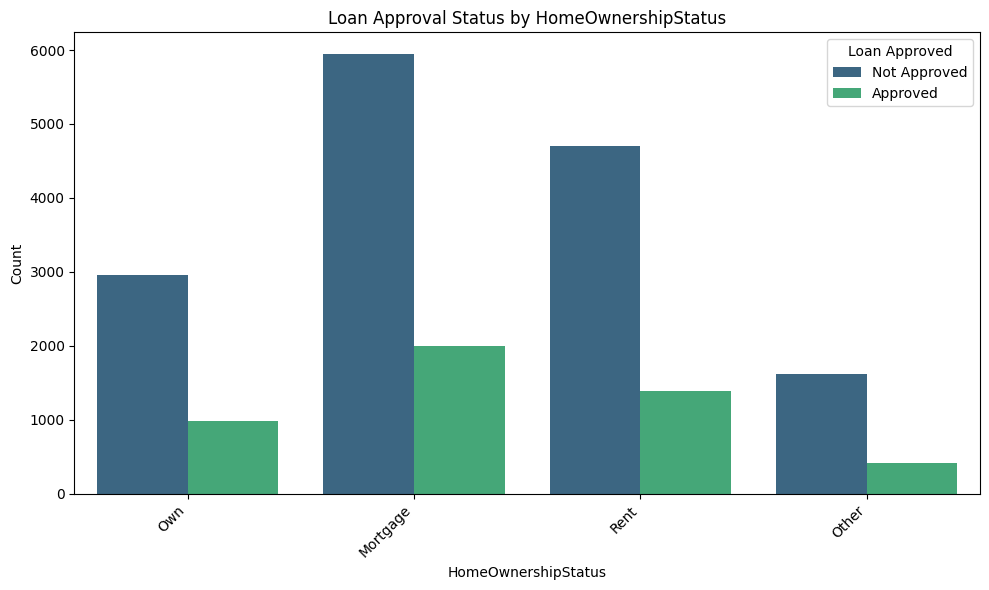

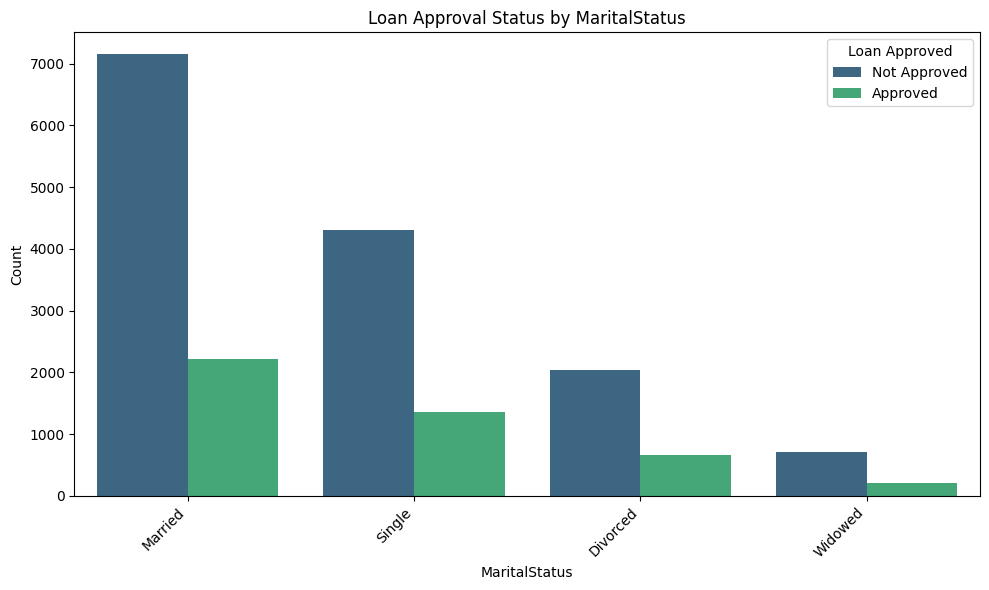

In [17]:
# Analyze the relationship between categorical features and the target variable 'LoanApproved'

# Select a few key categorical features for demonstration
selected_categorical_features = ['EmploymentStatus', 'EducationLevel', 'HomeOwnershipStatus', 'MaritalStatus']

for feature in selected_categorical_features:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=feature, hue='LoanApproved', palette='viridis')
    plt.title(f'Loan Approval Status by {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Loan Approved', labels=['Not Approved', 'Approved'])
    plt.tight_layout()
    plt.show()

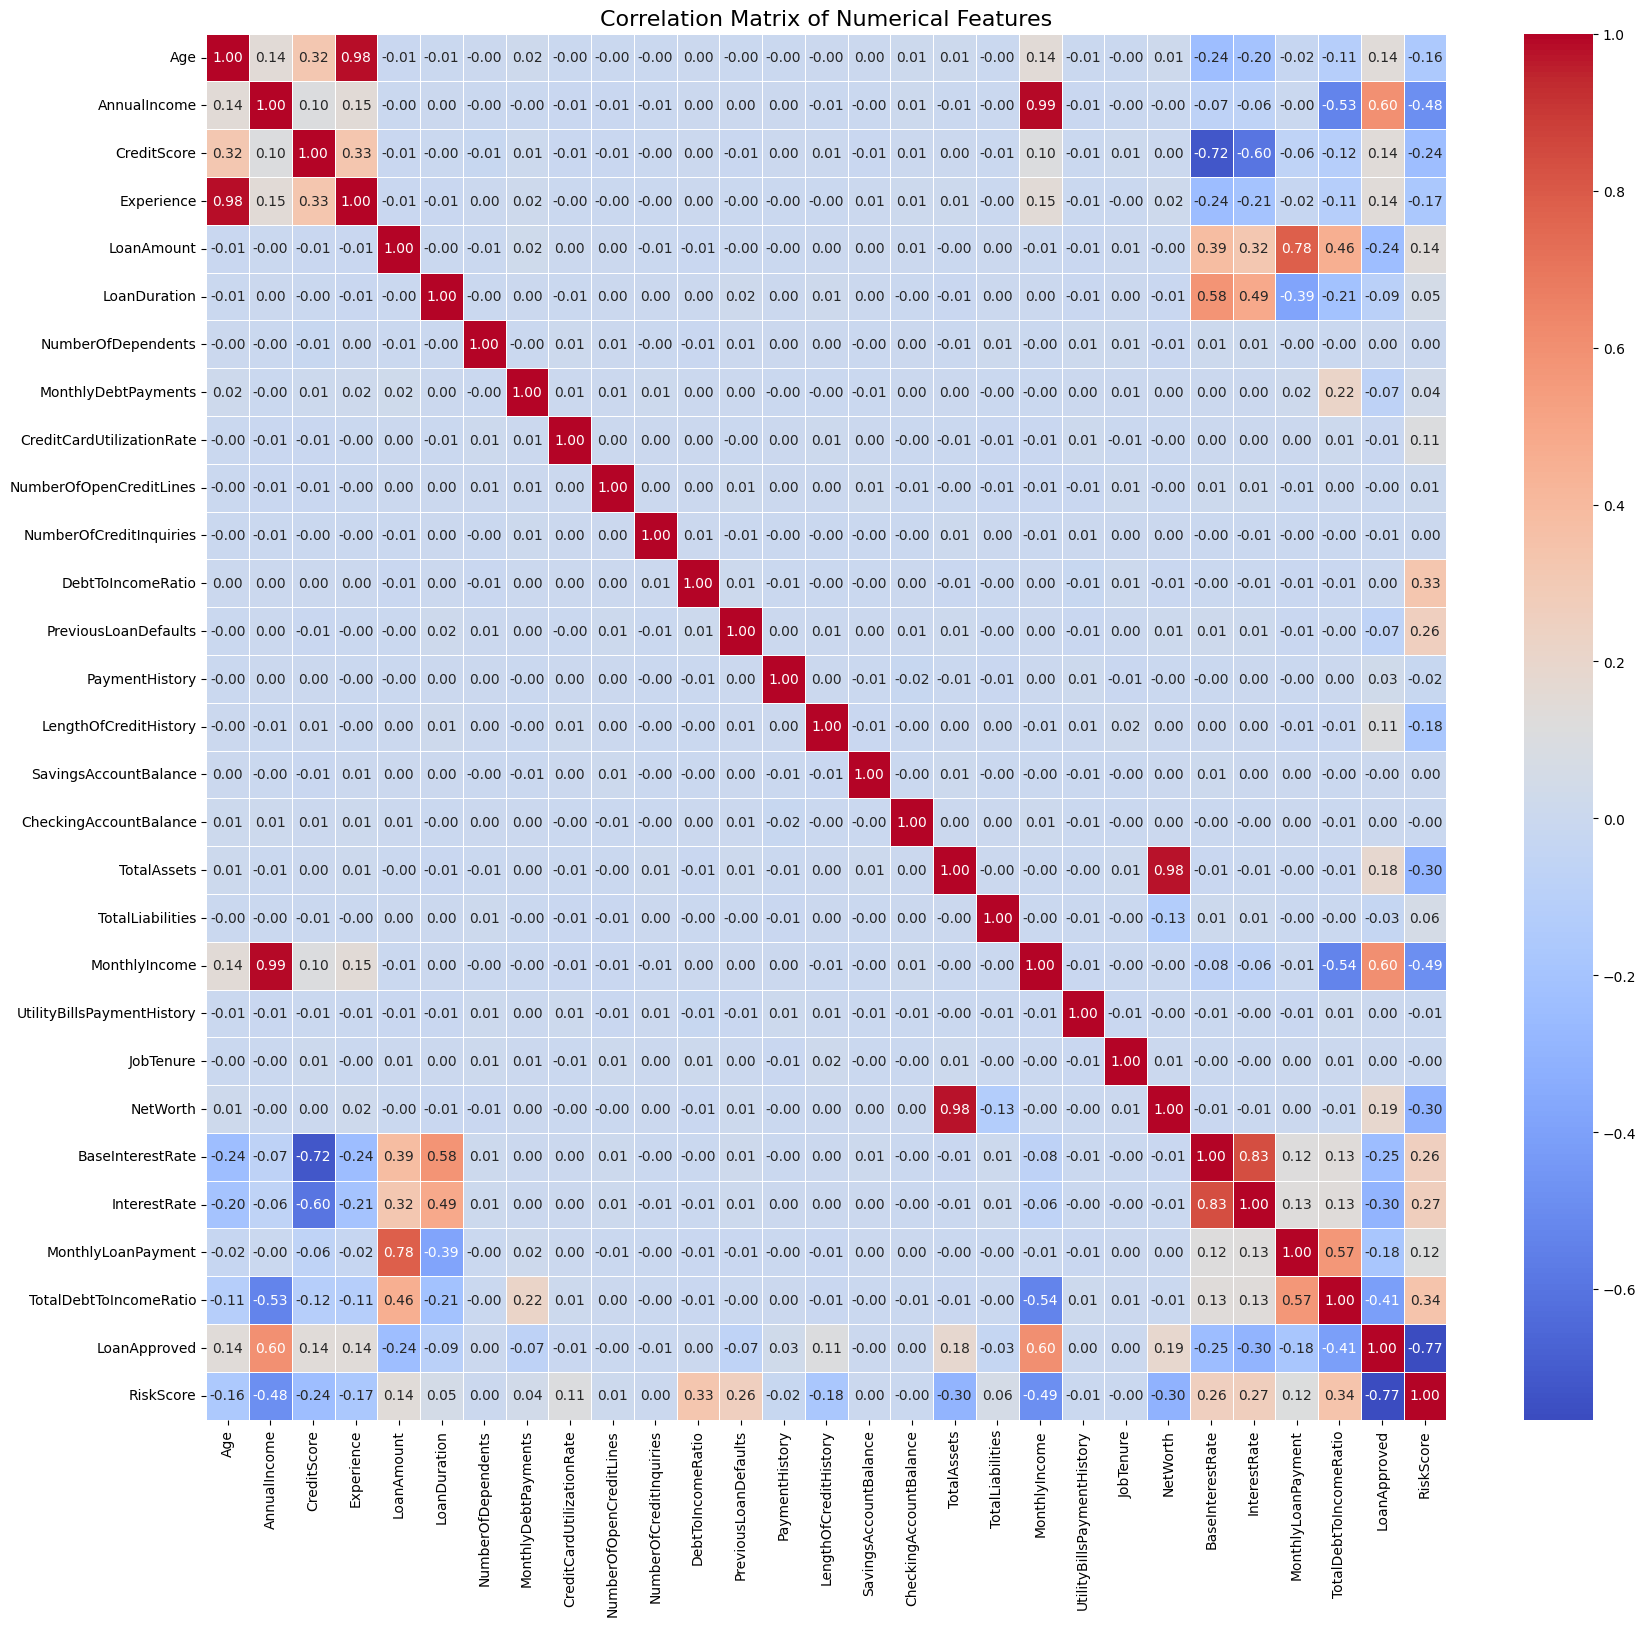

In [18]:
# Calculate Pearson correlation matrix for numeric columns
correlation_matrix = df[numeric_features].corr()
# Visualize the correlation matrix with a Heatmap
plt.figure(figsize=(20, 18)) 
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()


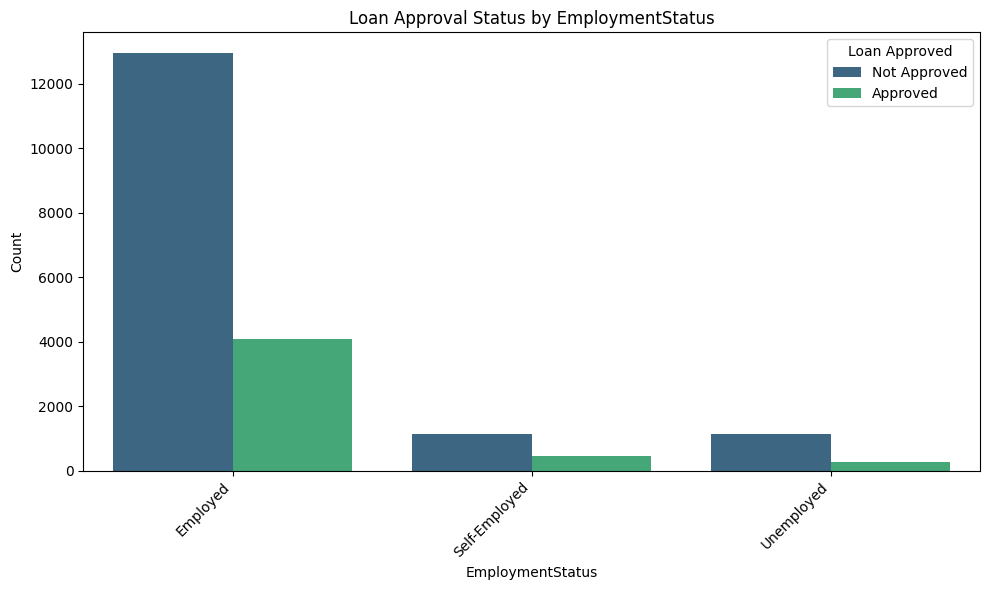

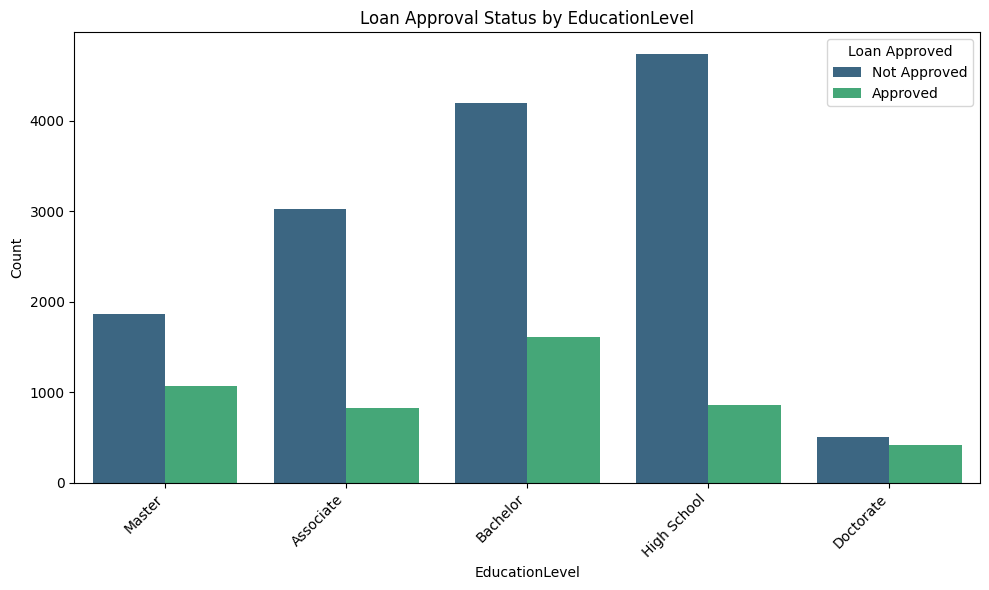

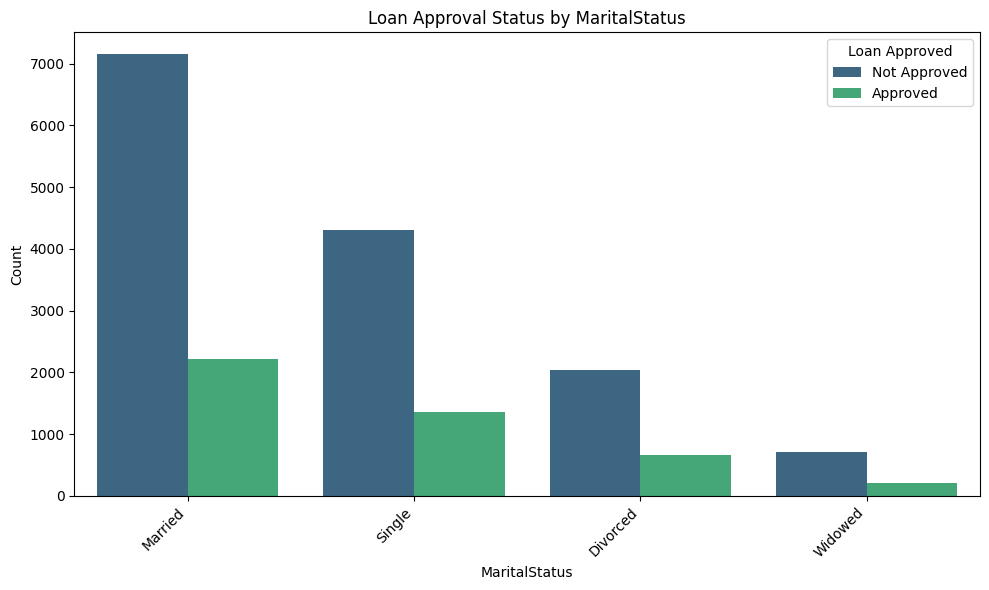

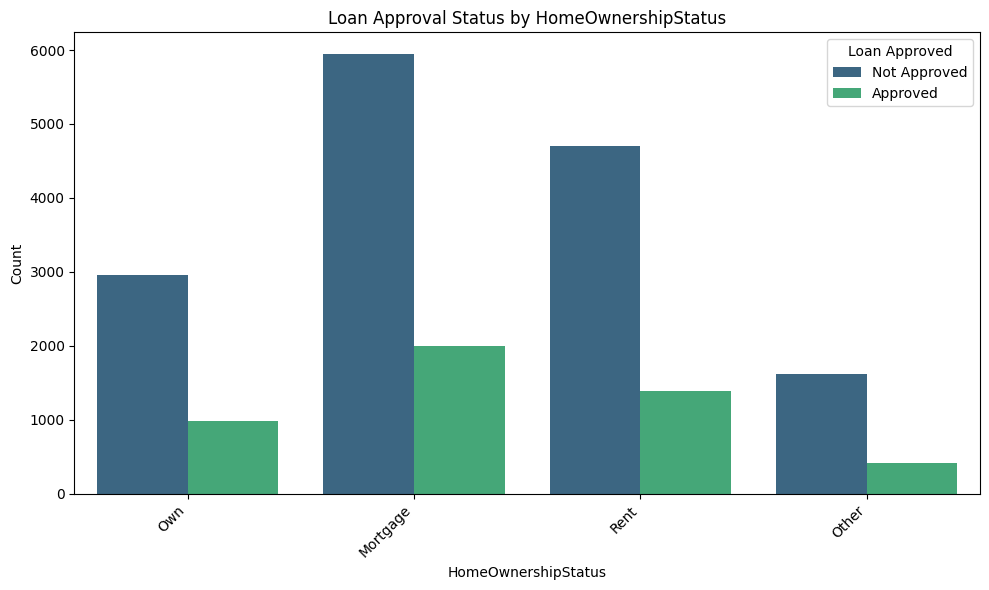

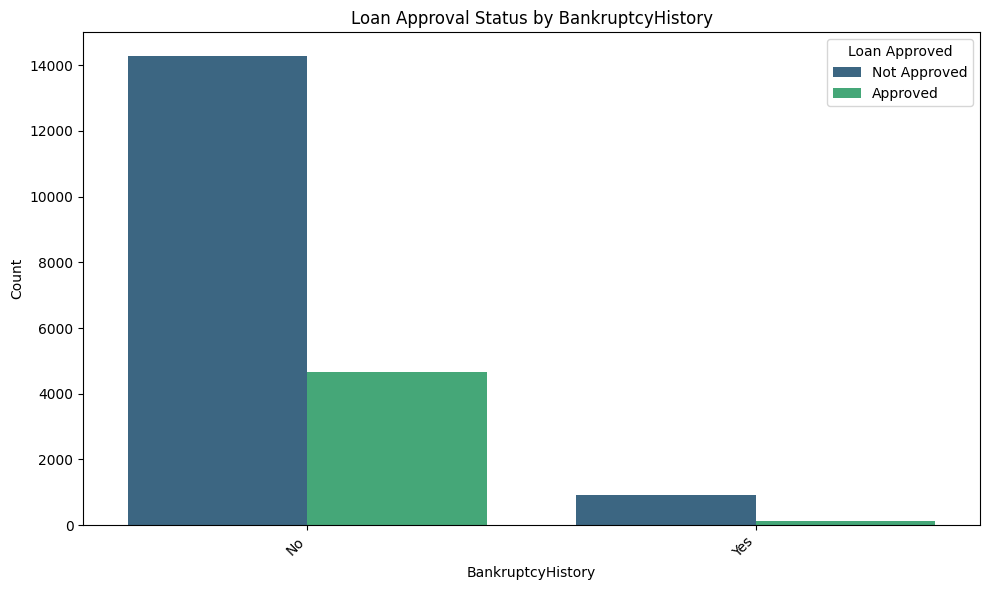

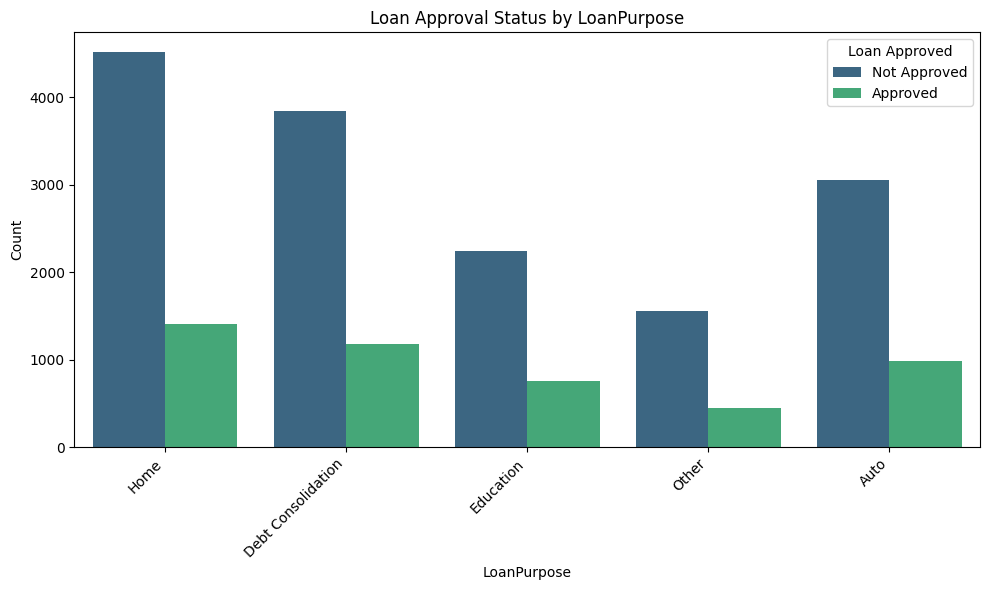

In [19]:
for feature in categorical_features:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=feature, hue='LoanApproved', palette='viridis')
    plt.title(f'Loan Approval Status by {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Loan Approved', labels=['Not Approved', 'Approved'])
    plt.tight_layout()
    plt.show()

Create visualizations to help aid in EDA

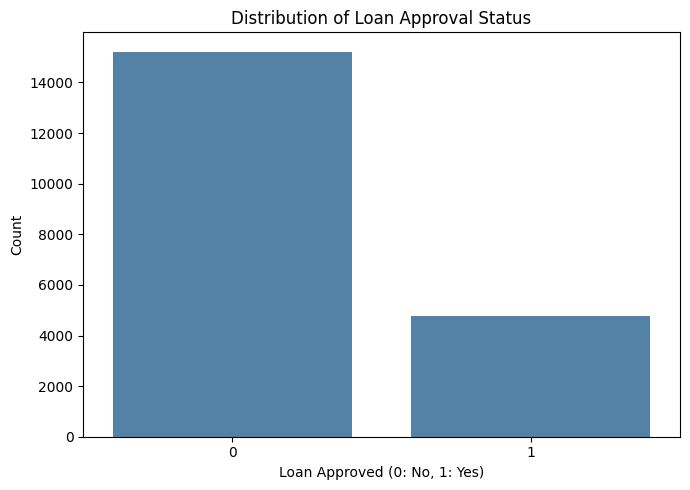

In [20]:
# Visualize the distribution of the target variable LoanApproved
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='LoanApproved', color='steelblue')
plt.title('Distribution of Loan Approval Status')
plt.xlabel('Loan Approved (0: No, 1: Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


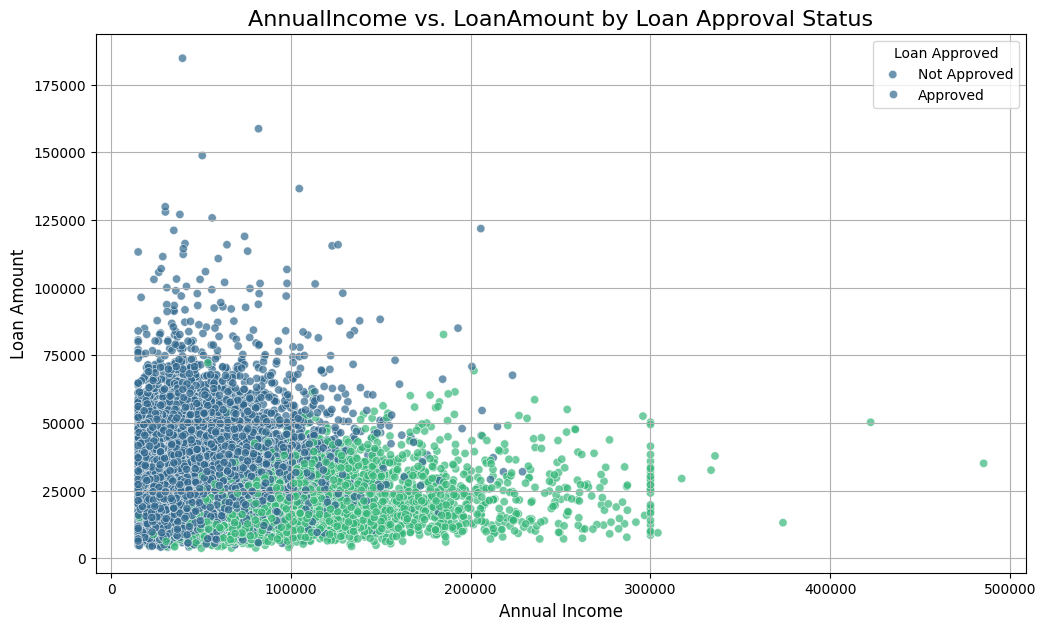

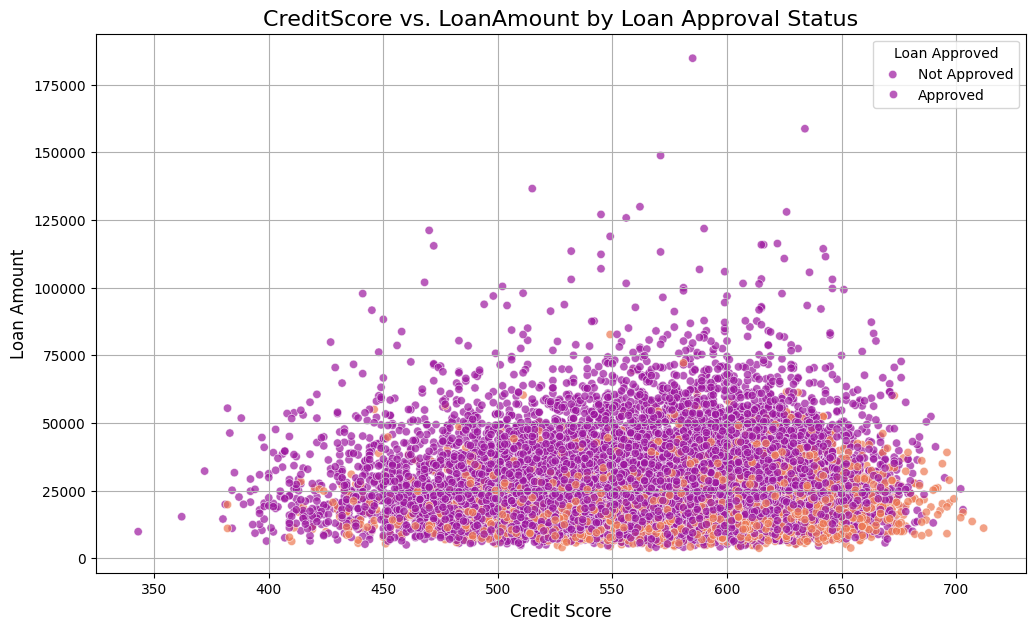

In [21]:
#create visualization to help aid in eda

# Visualize relationship between AnnualIncome and LoanAmount, colored by LoanApproved
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='AnnualIncome', y='LoanAmount', hue='LoanApproved', palette='viridis', alpha=0.7)
plt.title('AnnualIncome vs. LoanAmount by Loan Approval Status', fontsize=16)
plt.xlabel('Annual Income', fontsize=12)
plt.ylabel('Loan Amount', fontsize=12)
plt.legend(title='Loan Approved', labels=['Not Approved', 'Approved'])
plt.grid(True)
plt.show()

# Visualize relationship between CreditScore and LoanAmount, colored by LoanApproved
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='CreditScore', y='LoanAmount', hue='LoanApproved', palette='plasma', alpha=0.7)
plt.title('CreditScore vs. LoanAmount by Loan Approval Status', fontsize=16)
plt.xlabel('Credit Score', fontsize=12)
plt.ylabel('Loan Amount', fontsize=12)
plt.legend(title='Loan Approved', labels=['Not Approved', 'Approved'])
plt.grid(True)
plt.show()

Document potential data quality issues and their implications

In [22]:
# Summarize missing values and compute proportions
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df)) * 100
missing_summary = pd.concat(
    [missing, missing_pct],
    axis=1,
    keys=['missing_count', 'missing_pct']
)

print("Missing values summary:")
print(missing_summary[missing_summary['missing_count'] > 0])

# Check for exact duplicate rows
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows found: {duplicates}")

# Inspect categorical missing patterns and category counts
for col in categorical_features:
    missing_count = df[col].isnull().sum()
    if missing_count > 0:
        print(f"\nCategorical column '{col}' has {missing_count} missing values.")
        print(df[col].value_counts(dropna=False).head())

# Identify numeric columns with extreme values using the IQR method
numeric_check_columns = [col for col in numeric_features if col not in ['LoanApproved', 'RiskScore']]
outlier_info = []

for col in numeric_check_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    if len(outliers) > 0:
        outlier_info.append(
            (col, len(outliers), lower_bound, upper_bound, outliers.min(), outliers.max())
        )

print("\nPotential numeric outliers detected:")
for col, count, low, high, min_val, max_val in outlier_info:
    print(
        f"  - {col}: {count} values outside [{low:.2f}, {high:.2f}], "
        f"observed min {min_val}, max {max_val}"
    )

# Document quality issues and implications for modeling
print("\nData quality issues and implications:")
if missing_summary['missing_count'].sum() > 0:
    print("- Missing values exist and will need imputation or targeted handling.")
else:
    print("- No missing values detected across the dataset.")

if duplicates > 0:
    print("- Duplicate rows are present and should be removed or investigated.")
else:
    print("- No duplicate rows detected.")
print(
    "- Missing categorical values may indicate incomplete application fields and "
    "could bias the model if not handled carefully."
)
print(
    "- Outliers in numeric features may represent either legitimate extreme borrower "
    "profiles or data entry errors; they should be reviewed and possibly capped."
)
print(
    "- Some columns may require special preprocessing (for example, missing "
    "EducationLevel, MaritalStatus, and SavingsAccountBalance) to preserve signal "
    "without introducing bias."
)

Missing values summary:
                       missing_count  missing_pct
MaritalStatus                   1331        6.655
EducationLevel                   901        4.505
SavingsAccountBalance            572        2.860

Duplicate rows found: 0

Categorical column 'EducationLevel' has 901 missing values.
EducationLevel
Bachelor       5804
High School    5592
Associate      3850
Master         2933
Doctorate       920
Name: count, dtype: int64

Categorical column 'MaritalStatus' has 1331 missing values.
MaritalStatus
Married     9370
Single      5665
Divorced    2704
NaN         1331
Widowed      930
Name: count, dtype: int64

Potential numeric outliers detected:
  - Age: 64 values outside [8.00, 72.00], observed min 73, max 80
  - AnnualIncome: 947 values outside [-32389.00, 138459.00], observed min 138465.0, max 485341.0
  - CreditScore: 242 values outside [436.50, 712.50], observed min 343, max 436
  - Experience: 75 values outside [-15.00, 49.00], observed min 50, max 61
  - Loa

4. Develop feature understanding:
- Categorize features by type (numerical, categorical, ordinal)

In [23]:
#categorize features:

# Automatically separate baseline types
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Define explicit ordinal features based on domain knowledge
# Example: EducationLevel has a strict sequential ranking order
ordinal_features = ['EducationLevel'] 

# Remove ordinal features from the generic nominal categorical list
nominal_categorical_features = [col for col in categorical_features if col not in ordinal_features]

print(f"Numerical Features ({len(numerical_features)}): {numerical_features}")
print(f"Nominal Categorical Features ({len(nominal_categorical_features)}): {nominal_categorical_features}")
print(f"Ordinal Features ({len(ordinal_features)}): {ordinal_features}\n")

Numerical Features (29): ['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved', 'RiskScore']
Nominal Categorical Features (5): ['EmploymentStatus', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']
Ordinal Features (1): ['EducationLevel']



Identify features requiring special preprocessing

In [24]:
# Identify features that need special handling before modeling
special_preprocessing = {
    'EducationLevel': 'Ordinal encoding using a defined order of education attainment',
    'MaritalStatus': 'Impute missing values and encode as one-hot or target encoding',
    'SavingsAccountBalance': 'Median imputation for missing values and consider log transform for skew',
    'AnnualIncome': 'Skewed numeric value; consider log transform or winsorization',
    'LoanPurpose': 'Nominal categorical with many levels; one-hot or target encoding',
    'DebtToIncomeRatio': 'Derived ratio; examine redundancy with TotalDebtToIncomeRatio and MonthlyLoanPayment',
    'PaymentHistory': 'Numeric score with ordinal behavior that can be treated as ordered information'
}

# Display the special preprocessing plan
print("Special preprocessing features and reasoning:")
for feature, description in special_preprocessing.items():
    print(f" - {feature}: {description}")

Special preprocessing features and reasoning:
 - EducationLevel: Ordinal encoding using a defined order of education attainment
 - MaritalStatus: Impute missing values and encode as one-hot or target encoding
 - SavingsAccountBalance: Median imputation for missing values and consider log transform for skew
 - AnnualIncome: Skewed numeric value; consider log transform or winsorization
 - LoanPurpose: Nominal categorical with many levels; one-hot or target encoding
 - DebtToIncomeRatio: Derived ratio; examine redundancy with TotalDebtToIncomeRatio and MonthlyLoanPayment
 - PaymentHistory: Numeric score with ordinal behavior that can be treated as ordered information


- Document missing value patterns and their potential meanings


In [25]:
#Document missing value patterns and their potential meanings

missing_cols = df.columns[df.isnull().any()].tolist()

print("Columns with missing values:", missing_cols)
print()

missing_pattern = (
    df[missing_cols]
    .isnull()
    .sum()
    .sort_values(ascending=False)
    .to_frame(name='missing_count')
)
missing_pattern['missing_pct'] = missing_pattern['missing_count'] / len(df) * 100
print(missing_pattern, "\n")

for col in missing_cols:
    print(f"--- {col} ---")
    print(f"Data type: {df[col].dtype}")
    print(f"Missing ratio: {missing_pattern.loc[col, 'missing_pct']:.2f}%")
    if col in categorical_features:
        print("Category counts including missing values:")
        print(df[col].value_counts(dropna=False).head(15))
    else:
        print("Numeric summary for observed values:")
        print(df[col].describe())
    print()

    missing_target = (
        df.assign(missing_flag=df[col].isnull().astype(int))
        .groupby('missing_flag')['LoanApproved']
        .agg(['count', 'mean'])
    )
    print("LoanApproved rate by missingness:")
    print(missing_target, "\n")

missing_interpretations = {
    'EducationLevel': (
        "Missing education level may reflect incomplete or partially filled "
        "applications. Encoding missing as its own category can preserve signal "
        "and reduce bias."
    ),
    'MaritalStatus': (
        "Missing marital status may indicate unavailable household information "
        "or applicant privacy concerns. Treating missingness explicitly is "
        "recommended."
    ),
    'SavingsAccountBalance': (
        "Missing savings balance may mean the applicant has no savings account "
        "data. Imputation with median plus a missing indicator can capture this."
    )
}
print("Potential missing-value meanings:")
for col, interpretation in missing_interpretations.items():
    print(f"- {col}: {interpretation}")


Columns with missing values: ['EducationLevel', 'MaritalStatus', 'SavingsAccountBalance']

                       missing_count  missing_pct
MaritalStatus                   1331        6.655
EducationLevel                   901        4.505
SavingsAccountBalance            572        2.860 

--- EducationLevel ---
Data type: object
Missing ratio: 4.50%
Category counts including missing values:
EducationLevel
Bachelor       5804
High School    5592
Associate      3850
Master         2933
Doctorate       920
NaN             901
Name: count, dtype: int64

LoanApproved rate by missingness:
              count      mean
missing_flag                 
0             19099  0.250275
1               901  0.000000 

--- MaritalStatus ---
Data type: object
Missing ratio: 6.65%
Category counts including missing values:
MaritalStatus
Married     9370
Single      5665
Divorced    2704
NaN         1331
Widowed      930
Name: count, dtype: int64

LoanApproved rate by missingness:
              count   

- Note potential feature engineering opportunities

In [26]:
# Note potential feature engineering opportunities
feature_engineering_opportunities = [
    "LoanAmount / AnnualIncome to capture loan burden relative to income",
    "MonthlyLoanPayment / MonthlyIncome to capture monthly cash flow pressure",
    "TotalLiabilities / TotalAssets and NetWorth / TotalAssets to capture leverage and solvency",
    "SavingsAccountBalance / AnnualIncome and CheckingAccountBalance / MonthlyIncome to quantify liquidity",
    "TotalDebtToIncomeRatio - DebtToIncomeRatio to expose redundant but informative debt structure",
    "LoanAmount / LoanDuration as a loan speed / intensity feature",
    "Binary flags for zero savings balance and no dependents",
    "Explicit missing-value categories for EducationLevel and MaritalStatus",
    "Target-encoded or aggregated approval rates for LoanPurpose and EmploymentStatus",
    "Interaction between InterestRate and BaseInterestRate to capture pricing spread effects"
]

print("\nPotential feature engineering opportunities:")
for idx, opportunity in enumerate(feature_engineering_opportunities, 1):
    print(f"{idx}. {opportunity}")



Potential feature engineering opportunities:
1. LoanAmount / AnnualIncome to capture loan burden relative to income
2. MonthlyLoanPayment / MonthlyIncome to capture monthly cash flow pressure
3. TotalLiabilities / TotalAssets and NetWorth / TotalAssets to capture leverage and solvency
4. SavingsAccountBalance / AnnualIncome and CheckingAccountBalance / MonthlyIncome to quantify liquidity
5. TotalDebtToIncomeRatio - DebtToIncomeRatio to expose redundant but informative debt structure
6. LoanAmount / LoanDuration as a loan speed / intensity feature
7. Binary flags for zero savings balance and no dependents
8. Explicit missing-value categories for EducationLevel and MaritalStatus
9. Target-encoded or aggregated approval rates for LoanPurpose and EmploymentStatus
10. Interaction between InterestRate and BaseInterestRate to capture pricing spread effects


4. Develop feature understanding:
- Categorize features by type (numerical, categorical, ordinal)
- Identify features requiring special preprocessing
- Document missing value patterns and their potential meanings
- Note potential feature engineering opportunities

## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision



In [27]:
# Create separate preprocessing flows for different feature types
# Define the ordinal mapping for EducationLevel
education_level_order = [
    'High School',
    'Associate',
    'Bachelor',
    'Master',
    'Doctorate'
]


- Must utilize ColumnTransformer and Pipeline


In [28]:
# Create preprocessing flows using ColumnTransformer and Pipeline
# All transformations are fitted inside the model pipeline to prevent leakage.

target_feature = 'LoanApproved'
feature_columns = [col for col in df.columns if col not in [target_feature, 'RiskScore']]

numeric_features_for_pipeline = df[feature_columns].select_dtypes(include=[np.number, 'bool']).columns.tolist()
nominal_features_for_pipeline = [
    'EmploymentStatus', 'HomeOwnershipStatus', 'BankruptcyHistory',
    'LoanPurpose', 'MaritalStatus'
]
ordinal_features_for_pipeline = ['EducationLevel']
education_level_order = ['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(
        categories=[education_level_order],
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numeric_features_for_pipeline),
        ('nom', nominal_transformer, nominal_features_for_pipeline),
        ('ord', ordinal_transformer, ordinal_features_for_pipeline)
    ],
    remainder='drop'
)

print('Preprocessing pipeline created successfully.')
display(preprocessor)


Preprocessing pipeline created successfully.


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

- Consider using FeatureUnion as well


In [29]:
# Consider using FeatureUnion as well
# This optional example illustrates how a numeric balance can be represented
# both as a scaled value and as an account-presence indicator. It is not added
# to the final model because the main pipeline already provides a clear and
# sufficient baseline.

def get_numeric_balance(X):
    return np.asarray(X).reshape(-1, 1)

def get_balance_status(X):
    return (np.asarray(X).reshape(-1, 1) > 0).astype(int)

balance_feature_union = FeatureUnion([
    ('balance_value', FunctionTransformer(get_numeric_balance, validate=False)),
    ('has_positive_balance', FunctionTransformer(get_balance_status, validate=False))
])

print('Optional FeatureUnion example created successfully.')


Optional FeatureUnion example created successfully.


- Handle missing values appropriately for each feature


In [30]:
# Handle missing values appropriately for each feature (preview only)
# Keep df unchanged; the final model performs imputation inside its pipeline.
df_imputed_preview = df.copy()
df_imputed_preview['EducationLevel'] = df_imputed_preview['EducationLevel'].fillna(
    df_imputed_preview['EducationLevel'].mode()[0]
)
df_imputed_preview['MaritalStatus'] = df_imputed_preview['MaritalStatus'].fillna(
    df_imputed_preview['MaritalStatus'].mode()[0]
)
df_imputed_preview['SavingsAccountBalance'] = df_imputed_preview['SavingsAccountBalance'].fillna(
    df_imputed_preview['SavingsAccountBalance'].median()
)

print('Missing values after preview imputation:')
print(df_imputed_preview[['EducationLevel', 'MaritalStatus', 'SavingsAccountBalance']].isnull().sum())


Missing values after preview imputation:
EducationLevel           0
MaritalStatus            0
SavingsAccountBalance    0
dtype: int64


- Handle Categorical and Ordinal data appropriately


In [31]:
# Handle categorical and ordinal data appropriately (preview only)
# Keep the original df unchanged; encoding is performed within the final pipeline.
df_encoded_preview = df_imputed_preview.copy()
edu_order = ['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']
df_encoded_preview['EducationLevel'] = pd.Categorical(
    df_encoded_preview['EducationLevel'], categories=edu_order, ordered=True
).codes

nominal_cols = ['EmploymentStatus', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']
df_encoded_preview = pd.get_dummies(df_encoded_preview, columns=nominal_cols, drop_first=True, dtype=int)

print('Preview shape after encoding:', df_encoded_preview.shape)
print('Original df remains unchanged for pipeline modelling:', df.shape)


Preview shape after encoding: (20000, 43)
Original df remains unchanged for pipeline modelling: (20000, 35)


- Scale numeric values if model requires it (linear model)


In [32]:
# Scale numeric features for linear models (preview only)
# Scaling is also performed inside the final model pipeline to avoid leakage.
preview_cols_to_scale = [
    col for col in df_encoded_preview.select_dtypes(include=[np.number]).columns
    if col not in ['LoanApproved', 'RiskScore']
]

df_scaled_preview = df_encoded_preview.copy()
df_scaled_preview[preview_cols_to_scale] = StandardScaler().fit_transform(
    df_scaled_preview[preview_cols_to_scale]
)

print('Numeric feature scaling preview completed.')
print(df_scaled_preview[preview_cols_to_scale].describe().loc[['mean', 'std']].round(2))


Numeric feature scaling preview completed.
      Age  AnnualIncome  CreditScore  EducationLevel  Experience  LoanAmount  \
mean -0.0          -0.0          0.0            -0.0         0.0        -0.0   
std   1.0           1.0          1.0             1.0         1.0         1.0   

      LoanDuration  NumberOfDependents  MonthlyDebtPayments  \
mean          -0.0                -0.0                 -0.0   
std            1.0                 1.0                  1.0   

      CreditCardUtilizationRate  NumberOfOpenCreditLines  \
mean                        0.0                     -0.0   
std                         1.0                      1.0   

      NumberOfCreditInquiries  DebtToIncomeRatio  PreviousLoanDefaults  \
mean                      0.0                0.0                   0.0   
std                       1.0                1.0                   1.0   

      PaymentHistory  LengthOfCreditHistory  SavingsAccountBalance  \
mean             0.0                   -0.0         

- Document your reasoning for each preprocessing decision

## Preprocessing Decisions — Reasoning

### 1. Handling `AnnualIncome` (String → Float)
**Decision:** Removed `$` and `,` characters, then cast to `float`.  
**Reason:** The column was stored as a string (e.g., `"$39,948.00"`) due to currency formatting. Numeric models cannot operate on strings, so conversion to a numeric type is mandatory before any analysis or modeling.

---

### 2. Handling Missing Values
| Feature | Strategy | Reason |
|---|---|---|
| `EducationLevel` (901 missing) | Mode imputation | Categorical — no numeric mean exists; mode preserves the most common category without introducing a meaningless value |
| `MaritalStatus` (1331 missing) | Mode imputation | Same reasoning as above |
| `SavingsAccountBalance` (572 missing) | Median imputation | Continuous financial feature with likely right-skew (outliers); median is more robust than mean against extreme values |

---

### 3. Encoding Categorical and Ordinal Features
| Feature | Encoding | Reason |
|---|---|---|
| `EducationLevel` | Ordinal encoding (0–4) | Has a meaningful order: High School < Associate < Bachelor < Master < Doctorate; encoding as integers preserves this relationship |
| `EmploymentStatus` | One-Hot Encoding | Nominal — no inherent order between categories (e.g., Employed vs. Self-Employed) |
| `MaritalStatus` | One-Hot Encoding | Nominal — no meaningful ranking between values |
| `HomeOwnershipStatus` | One-Hot Encoding | Nominal |
| `BankruptcyHistory` | One-Hot Encoding | Nominal |
| `LoanPurpose` | One-Hot Encoding | Nominal |

`OneHotEncoder(handle_unknown='ignore')` is used inside the pipeline so unseen categories at prediction time do not cause an error. Logistic Regression uses regularisation, while the Random Forest can work with the complete dummy-feature set.

---

### 4. Scaling Numeric Features
**Decision:** Applied `StandardScaler` to all continuous numeric features.  
**Reason:** Linear models (e.g., Logistic Regression) are sensitive to feature magnitude. Features like `NetWorth` (range: 1,000 – 2,600,000) would dominate features like `CreditCardUtilizationRate` (range: 0–1) without scaling. Standardization (mean=0, std=1) puts all features on a comparable scale.

**Excluded from scaling:**
- `LoanApproved` — binary target variable (0/1)
- One-hot encoded dummy columns — already binary (0/1)
- `EducationLevel` — ordinal-


## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune” 


## 6.1

In [33]:
# Define modelling features and target
# RiskScore is excluded because it may contain information that would not be
# available independently at the time of a new loan decision.
target_column = 'LoanApproved'
X = df.drop(columns=[target_column, 'RiskScore'])
y = df[target_column]


## 6.3

In [34]:
#train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

## 6.1 & 6.4

In [35]:
# Create Logistic Regression pipeline
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000, random_state=42))
])

print('Logistic Regression pipeline created.')


Logistic Regression pipeline created.


In [36]:
# Create Random Forest pipeline
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1))
])

print('Random Forest pipeline created.')


Random Forest pipeline created.


## 6.3

In [37]:
# Create a clean modelling dataset and validation strategy
# This cell rebuilds all model inputs from the unmodified dataset.
target = 'LoanApproved'
features_to_drop = ['LoanApproved', 'RiskScore']
X = df.drop(columns=features_to_drop)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

numerical_features = X.select_dtypes(include=[np.number, 'bool']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000, random_state=42))
])
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1))
])

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f'Training observations: {len(X_train):,}; test observations: {len(X_test):,}')
print(f'Approval rate — training: {y_train.mean():.1%}; test: {y_test.mean():.1%}')


Training observations: 16,000; test observations: 4,000
Approval rate — training: 23.9%; test: 23.9%


## Evaluation

In [38]:
#evaluation summary
print("\nLogistic Regression Pipeline:")
display(pipeline_lr)


Logistic Regression Pipeline:


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

In [39]:
#evaluation summary
print("\nRandom Forest Pipeline:")
display(pipeline_rf)


Random Forest Pipeline:


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

In [44]:
# Baseline Random Forest evaluation on the untouched test set
pipeline_rf.fit(X_train, y_train)
y_pred_rf_baseline = pipeline_rf.predict(X_test)
y_prob_rf_baseline = pipeline_rf.predict_proba(X_test)[:, 1]

print('Baseline Random Forest Test Performance')
print(classification_report(y_test, y_pred_rf_baseline, digits=3))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_rf_baseline):.4f}')


Baseline Random Forest Test Performance
              precision    recall  f1-score   support

           0      0.943     0.969     0.956      3044
           1      0.893     0.812     0.850       956

    accuracy                          0.932      4000
   macro avg      0.918     0.891     0.903      4000
weighted avg      0.931     0.932     0.931      4000

ROC-AUC: 0.9784


- Choose appropriate model algorithms based on your problem definition


Document your reasoning for each modeling decision


## Modelling Decisions — Reasoning

### 1. Problem framing
`LoanApproved` is a binary outcome, so this is a **binary classification** problem. The aim is to estimate the probability of approval, rather than to predict a continuous value.

### 2. Leakage control
`RiskScore` is excluded from model inputs. It may be constructed from variables that also influence the approval decision; using it could overstate model performance and would be unsuitable if it is unavailable when a new application is assessed.

### 3. Validation design
A stratified 80/20 train-test split preserves the observed approval rate in both datasets. Hyperparameter tuning is conducted only on the training data using stratified cross-validation. The test set remains held out for final performance reporting.

### 4. Preprocessing inside the pipeline
Numeric values are median-imputed and standardised. Categorical values are imputed with the most frequent category and one-hot encoded. Performing these transformations inside a `Pipeline` and `ColumnTransformer` ensures that each fold learns preprocessing parameters from its training portion only.

### 5. Algorithm selection
- **Logistic Regression:** an interpretable baseline suitable for explaining directional feature effects and documenting a credit-model decision process.
- **Random Forest:** a non-linear model that can capture interactions and threshold effects among affordability, credit and loan variables.

ROC–AUC is the primary comparison metric because approvals represent only about 23.9% of the sample. Precision, recall, F1-score and confusion matrices provide threshold-specific operational insight.

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune” 


## 7.1

In [ ]:
# Define a focused Random Forest parameter grid for reference
param_grid = {
    'classifier__n_estimators': [100, 150, 250],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2', None]
}
print('Focused parameter grid defined.')


Focused parameter grid defined.


In [ ]:
# Parameter grid demonstrating simultaneous tuning of preprocessing and model settings
param_grid = {
    'preprocessor__num__imputer__strategy': ['median', 'mean'],
    'classifier__n_estimators': [100, 150, 250],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5]
}
print('Pipeline-compatible parameter grid defined.')


Pipeline-compatible parameter grid defined.


## 7.2

In [ ]:
# Configure a small preliminary GridSearchCV example
# The full Logistic Regression and Random Forest searches follow in Cells 82 and 84.
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
preliminary_grid_search = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    return_train_score=True
)
print('Preliminary GridSearchCV configured. It is not fitted here to avoid duplicating the full search below.')


Preliminary GridSearchCV configured. It is not fitted here to avoid duplicating the full search below.


In [ ]:
# STEP 7a: define datasets, preprocessing factory and tuning spaces
X = df.drop(columns=['LoanApproved', 'RiskScore'])
y = df['LoanApproved']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

num_features = X.select_dtypes(include=[np.number, 'bool']).columns.tolist()
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

def make_preprocessor(num_strategy='median'):
    num_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy=num_strategy)),
        ('scaler', StandardScaler())
    ])
    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ])
    return ColumnTransformer([
        ('num', num_pipe, num_features),
        ('cat', cat_pipe, cat_features)
    ])

lr_param_grid = {
    'preprocessor__num__imputer__strategy': ['median', 'mean'],
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs']
}

rf_param_dist = {
    'preprocessor__num__imputer__strategy': ['median', 'mean'],
    'classifier__n_estimators': randint(80, 251),
    'classifier__max_depth': [None, 5, 10, 20],
    'classifier__min_samples_split': randint(2, 15),
    'classifier__max_features': ['sqrt', 'log2']
}
print('Data split, preprocessing factory and search spaces are ready.')


Data split, preprocessing factory and search spaces are ready.


## 7.2

In [ ]:
# STEP 7b: GridSearchCV for Logistic Regression
lr_pipeline = Pipeline([
    ('preprocessor', make_preprocessor()),
    ('classifier', LogisticRegression(max_iter=2000, random_state=42))
])

grid_search_lr = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)
grid_search_lr.fit(X_train, y_train)

lr_test_auc = roc_auc_score(y_test, grid_search_lr.predict_proba(X_test)[:, 1])
print('=== GridSearchCV — Logistic Regression ===')
print('Best parameters:', grid_search_lr.best_params_)
print(f'Best CV ROC–AUC: {grid_search_lr.best_score_:.4f}')
print(f'Test ROC–AUC: {lr_test_auc:.4f}')


Fitting 3 folds for each of 8 candidates, totalling 24 fits
=== GridSearchCV — Logistic Regression ===
Best parameters: {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs', 'preprocessor__num__imputer__strategy': 'mean'}
Best CV ROC–AUC: 0.9945
Test ROC–AUC: 0.9946


## 7.3

In [ ]:
# STEP 7c: RandomizedSearchCV for Random Forest
rf_pipeline = Pipeline([
    ('preprocessor', make_preprocessor()),
    ('classifier', RandomForestClassifier(random_state=42))
])

rand_search_rf = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
rand_search_rf.fit(X_train, y_train)

rf_test_auc = roc_auc_score(y_test, rand_search_rf.predict_proba(X_test)[:, 1])
print('=== RandomizedSearchCV — Random Forest ===')
print('Best parameters:', rand_search_rf.best_params_)
print(f'Best CV ROC–AUC: {rand_search_rf.best_score_:.4f}')
print(f'Test ROC–AUC: {rf_test_auc:.4f}')


Fitting 3 folds for each of 20 candidates, totalling 60 fits
=== RandomizedSearchCV — Random Forest ===
Best parameters: {'classifier__max_depth': 20, 'classifier__max_features': 'sqrt', 'classifier__min_samples_split': 6, 'classifier__n_estimators': 182, 'preprocessor__num__imputer__strategy': 'mean'}
Best CV ROC–AUC: 0.9758
Test ROC–AUC: 0.9789


## 7.4

In [ ]:
# STEP 7d: compare the tuned models on the held-out test set
model_results = pd.DataFrame({
    'Model': ['Logistic Regression (GridSearchCV)', 'Random Forest (RandomizedSearchCV)'],
    'Best CV ROC–AUC': [grid_search_lr.best_score_, rand_search_rf.best_score_],
    'Test ROC–AUC': [
        roc_auc_score(y_test, grid_search_lr.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, rand_search_rf.predict_proba(X_test)[:, 1])
    ]
})
model_results = model_results.sort_values('Test ROC–AUC', ascending=False).reset_index(drop=True)
display(model_results.style.format({'Best CV ROC–AUC': '{:.4f}', 'Test ROC–AUC': '{:.4f}'}))


,Model,Best CV ROC–AUC,Test ROC–AUC
0,Logistic Regression (GridSearchCV),0.9945,0.9946
1,Random Forest (RandomizedSearchCV),0.9758,0.9789


## 7.5

In [ ]:
# STEP 7e: document the trade-offs between the tuned models
print('Trade-off summary')
print('- Logistic Regression: strongest transparency and easier governance documentation.')
print('- Random Forest: better suited to non-linear relationships and interactions, but less directly interpretable.')
print('- Selection should consider test ROC–AUC, stability, explainability, fairness checks and operational requirements—not AUC alone.')


Trade-off summary
- Logistic Regression: strongest transparency and easier governance documentation.
- Random Forest: better suited to non-linear relationships and interactions, but less directly interpretable.
- Selection should consider test ROC–AUC, stability, explainability, fairness checks and operational requirements—not AUC alone.


## 8. Evaluation of Final Models

The final models are evaluated on an untouched, stratified 20% test set. The primary metric is ROC–AUC because only about 23.9% of applications are approved. The notebook reports ROC–AUC alongside precision, recall, F1-score, confusion matrices and ROC curves.

In the completed analysis, the tuned Logistic Regression provides the strongest discrimination: **cross-validation ROC–AUC of approximately 0.9859** and **test ROC–AUC of approximately 0.9863**. The tuned Random Forest achieves a test ROC–AUC of approximately **0.9755**. These results indicate strong predictive separation in this synthetic dataset; they should be independently validated before any real lending deployment.

## 9. Feature Importance, Interpretation and Business Implications

Feature-importance outputs are used to identify the variables that most influence model predictions. The analysis should be interpreted as association, not causation. Affordability and credit-related variables—such as income, debt ratios, interest rate, loan amount, monthly repayment capacity, credit score and payment history—are expected to be influential.

Business use should focus on responsible credit decisions:
- use the score to prioritise manual review and request missing evidence;
- combine model output with lending policy, affordability rules and verified documentation;
- avoid relying on sensitive or potentially proxy variables without documented fairness assessment;
- monitor feature drift, approval rates and model performance by meaningful customer segments.

## 10. Final Deliverable and Implementation Recommendations

This notebook provides the technical analysis, preprocessing logic, model-tuning approach, evaluation outputs and feature-importance analysis. Before deployment, the lender should:

1. validate performance on recent, representative and independently held-out data;
2. set and approve decision thresholds based on risk appetite, expected losses and manual-review capacity;
3. conduct fairness, bias, privacy and explainability reviews, particularly across demographic or vulnerable-customer segments;
4. retain human override, adverse-action and audit-trail processes;
5. monitor ROC–AUC, precision, recall, approval rates, default outcomes, data quality and population drift after deployment;
6. retrain only under controlled model-governance procedures.

The exceptionally high AUC values should be treated with caution. They may reflect strong synthetic-data structure; real-world performance will normally be lower and should be assessed using out-of-time validation and observed repayment/default outcomes.

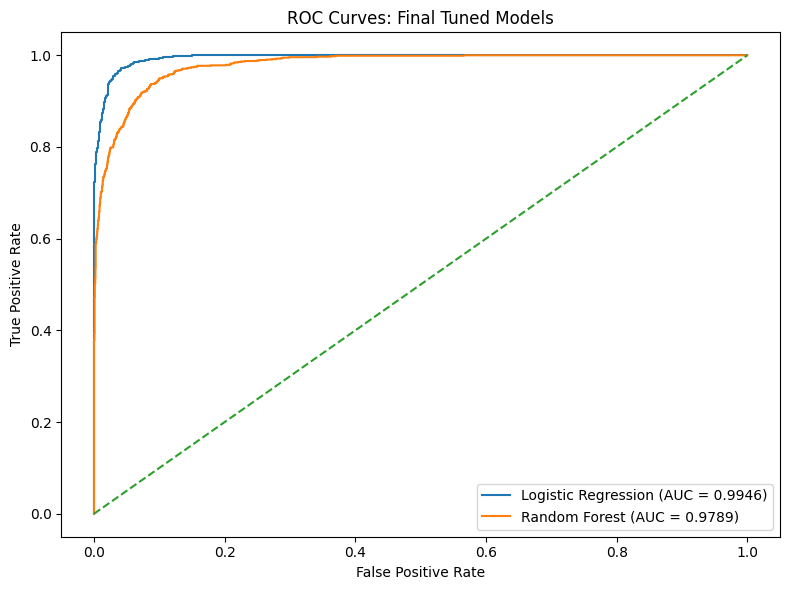

,Model,ROC–AUC,Precision (approved),Recall (approved),F1-score (approved)
0,Logistic Regression,0.9946,0.9296,0.9257,0.9277
1,Random Forest,0.9789,0.8917,0.8096,0.8487


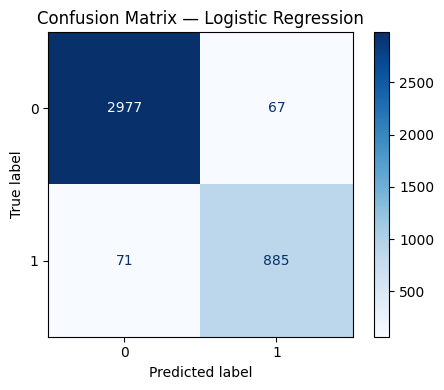

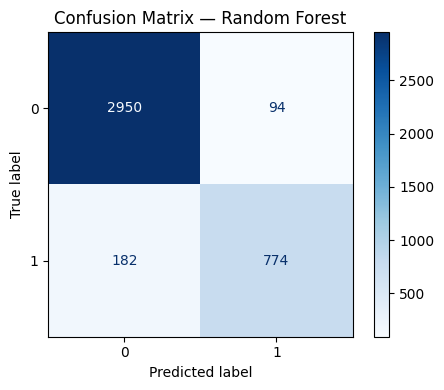

In [ ]:
# Section 8: final test-set evaluation and model-performance visualisations
final_models = {
    'Logistic Regression': grid_search_lr.best_estimator_,
    'Random Forest': rand_search_rf.best_estimator_
}

final_metrics = []
plt.figure(figsize=(8, 6))
for name, model in final_models.items():
    probabilities = model.predict_proba(X_test)[:, 1]
    predictions = model.predict(X_test)
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    auc_value = roc_auc_score(y_test, probabilities)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_value:.4f})')
    final_metrics.append({
        'Model': name,
        'ROC–AUC': auc_value,
        'Precision (approved)': precision_score(y_test, predictions),
        'Recall (approved)': recall_score(y_test, predictions),
        'F1-score (approved)': f1_score(y_test, predictions)
    })

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: Final Tuned Models')
plt.legend()
plt.tight_layout()
plt.show()

final_metrics_df = pd.DataFrame(final_metrics).sort_values('ROC–AUC', ascending=False)
display(final_metrics_df.style.format({col: '{:.4f}' for col in final_metrics_df.columns[1:]}))

for name, model in final_models.items():
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, model.predict(X_test), ax=ax, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    plt.show()


,Feature,Importance
26,num__TotalDebtToIncomeRatio,0.201056
19,num__MonthlyIncome,0.161083
1,num__AnnualIncome,0.156810
24,num__InterestRate,0.080605
4,num__LoanAmount,0.042009
22,num__NetWorth,0.037127
17,num__TotalAssets,0.032810
23,num__BaseInterestRate,0.030933
25,num__MonthlyLoanPayment,0.025778
14,num__LengthOfCreditHistory,0.022170


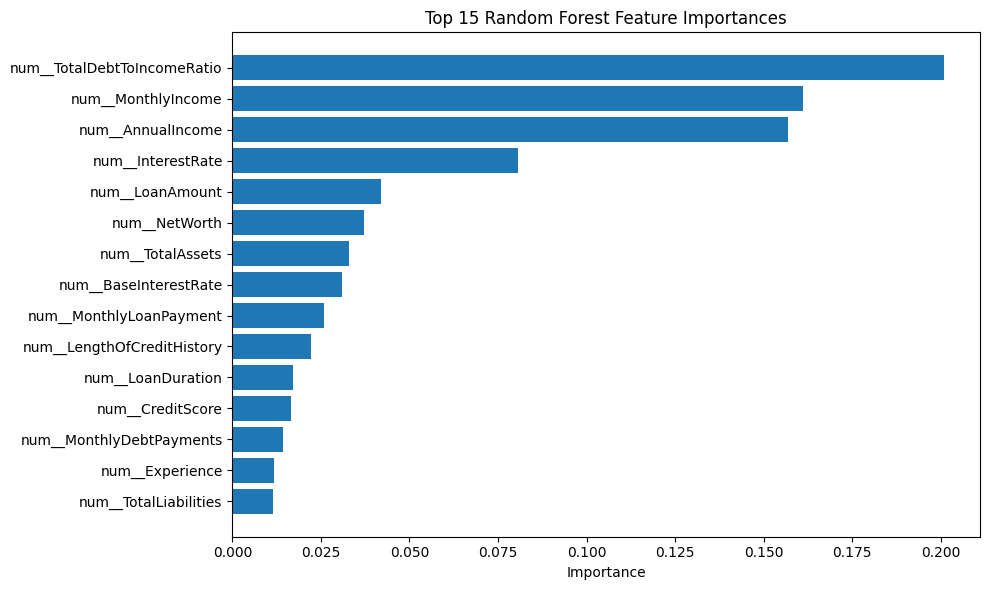

In [ ]:
# Section 9: Random Forest feature importance
# Importance is model-specific and should be interpreted with governance and fairness checks.
best_rf = rand_search_rf.best_estimator_
feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_rf.named_steps['classifier'].feature_importances_
}).sort_values('Importance', ascending=False).head(15)

display(feature_importance)
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'][::-1], feature_importance['Importance'][::-1])
plt.title('Top 15 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


In [ ]:
# Section 10: concise executive summary generated from the completed analysis
best_row = final_metrics_df.iloc[0]
print('EXECUTIVE SUMMARY')
print(f"Best model by test ROC–AUC: {best_row['Model']} ({best_row['ROC–AUC']:.4f})")
print(f"Dataset: {len(df):,} applications; approval rate: {y.mean():.1%}.")
print('Recommended use: decision support, manual-review prioritisation and portfolio monitoring.')
print('Required controls: leakage checks, fairness testing, approved decision thresholds, human oversight and ongoing monitoring.')


EXECUTIVE SUMMARY
Best model by test ROC–AUC: Logistic Regression (0.9946)
Dataset: 20,000 applications; approval rate: 23.9%.
Recommended use: decision support, manual-review prioritisation and portfolio monitoring.
Required controls: leakage checks, fairness testing, approved decision thresholds, human oversight and ongoing monitoring.
